# GMPE Model Comparison: ANN · BNN · BNN-Improved · CGAN · CVAE
## NGA-Sub Subduction Zone Dataset
### Systematic Performance Comparison Across All Five Architectures

---
This notebook trains and compares five deep-learning Ground Motion Prediction Equation (GMPE) models
on the NGA-Sub subduction zone flatfile, then generates a comprehensive suite of diagnostic plots.

| Model | Reference | Type | Uncertainty |
|-------|-----------|------|-------------|
| **ANN** | Vemula et al. (2023) | Feedforward | None (point estimate) |
| **BNN** | Vemula et al. (2025) | Bayesian NN | Epistemic (weight posterior) |
| **BNN-Improved** | This work | Bayesian + Heteroscedastic | Epistemic + Aleatory (learned σ) |
| **CGAN** | Sriwastav et al. (2025) | Generative Adversarial | Full distribution (adversarial) |
| **CVAE** | Sriwastav et al. (2025) | Conditional Variational AE | Full distribution (latent sampling) |

All models predict **ln(PSA)** at 105 spectral periods (T = 0.01–10 s) using 6 seismological inputs:
*Mw, RJB, ln(RJB), ln(Vs30), Focal Depth, Fault Mechanism Flag.*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, os, time, json
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, callbacks, Input, Model, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Plot style
plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.spines.top': False,
    'axes.spines.right': False,
})
os.makedirs('figures_comparison', exist_ok=True)

# ── Training configuration (reduce epochs for quick testing; increase for full training)
QUICK_MODE   = False          # Set True for fast demo (10 epochs each)
ANN_EPOCHS   = 10 if QUICK_MODE else 150
BNN_EPOCHS   = 10 if QUICK_MODE else 150
BNNX_EPOCHS  = 10 if QUICK_MODE else 150
CGAN_EPOCHS  = 10 if QUICK_MODE else 400
CVAE_EPOCHS  = 10 if QUICK_MODE else 150
BATCH_SIZE   = 256
BNN_SAMPLES  = 100           # Monte Carlo samples at inference
N_GEN        = 200           # GAN/CVAE ensemble size for uncertainty

MODEL_COLORS = {
    'ANN'         : '#2196F3',
    'BNN'         : '#FF5722',
    'BNN-Improved': '#9C27B0',
    'CGAN'        : '#4CAF50',
    'CVAE'        : '#FF9800',
}
MODEL_NAMES = list(MODEL_COLORS.keys())

print(f"TensorFlow : {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")
print(f"Quick mode : {QUICK_MODE}")


TensorFlow : 2.21.0
GPU devices: []
Quick mode : False


## 1  ·  Data Loading & Feature Engineering

In [2]:
CSV_PATH = 'NGAsub_flatfile_filtered.csv'
df = pd.read_csv(CSV_PATH)
print(f"Records : {len(df):,}  |  Events: {df['NGAsubEQID'].nunique()}  |  Stations: {df['NGAsubSSN'].nunique()}")
print(f"Mw      : {df['Earthquake_Magnitude'].min():.1f} – {df['Earthquake_Magnitude'].max():.1f}")
print(f"Rjb (km): {df['Rjb_km'].min():.1f} – {df['Rjb_km'].max():.1f}")
print(f"Vs30    : {df['Vs30_Selected_for_Analysis_m_s'].min():.0f} – {df['Vs30_Selected_for_Analysis_m_s'].max():.0f} m/s")
print()
print("Region distribution:")
print(df['DatabaseRegion'].value_counts().to_string())

# ── Region flag
REGION_MAP = {
    'Alaska':1,'Cascadia':2,'CentralAmerica&Mexico':3,
    'Japan':4,'SouthAmerica':5,'Taiwan':6,
}
REGION_NAMES  = {1:'AK',2:'CAS',3:'CAM',4:'JP',5:'SA',6:'TW'}
REGION_COLORS = {1:'#1f77b4',2:'#ff7f0e',3:'#d62728',4:'#9467bd',5:'#17becf',6:'#2ca02c'}

df['Region_Flag'] = df['DatabaseRegion'].map(REGION_MAP)
df['log_Rjb']    = np.log(df['Rjb_km'].clip(lower=0.01))
df['log_Vs30']   = np.log(df['Vs30_Selected_for_Analysis_m_s'])
df['FM']         = df['Intra_Inter_Flag'].map({0:1,1:2,5:3}).fillna(4)

# ── Unified 6-input vector (used by ALL models for fair comparison)
INPUT_COLS   = ['Earthquake_Magnitude','Rjb_km','log_Rjb','log_Vs30','Hypocenter_Depth_km','FM']
INPUT_LABELS = ['Mw','RJB (km)','ln(RJB)','ln(Vs30)','Depth (km)','FM Flag']

# ── 105 PSA spectral columns
PSA_COLS = [
    'T0pt010S','T0pt020S','T0pt022S','T0pt025S','T0pt029S','T0pt030S','T0pt032S','T0pt035S','T0pt036S','T0pt040S',
    'T0pt042S','T0pt044S','T0pt045S','T0pt046S','T0pt048S','T0pt050S','T0pt055S','T0pt060S','T0pt065S','T0pt067S',
    'T0pt070S','T0pt075S','T0pt080S','T0pt085S','T0pt090S','T0pt095S','T0pt100S','T0pt110S','T0pt120S','T0pt130S',
    'T0pt133S','T0pt140S','T0pt150S','T0pt160S','T0pt170S','T0pt180S','T0pt190S','T0pt200S','T0pt220S','T0pt240S',
    'T0pt250S','T0pt260S','T0pt280S','T0pt290S','T0pt300S','T0pt320S','T0pt340S','T0pt350S','T0pt360S','T0pt380S',
    'T0pt400S','T0pt420S','T0pt440S','T0pt450S','T0pt460S','T0pt480S','T0pt500S','T0pt550S','T0pt600S','T0pt650S',
    'T0pt667S','T0pt700S','T0pt750S','T0pt800S','T0pt850S','T0pt900S','T0pt950S','T1pt000S','T1pt100S','T1pt200S',
    'T1pt300S','T1pt400S','T1pt500S','T1pt600S','T1pt700S','T1pt800S','T1pt900S','T2pt000S','T2pt200S','T2pt400S',
    'T2pt500S','T2pt600S','T2pt800S','T3pt000S','T3pt200S','T3pt400S','T3pt500S','T3pt600S','T3pt800S','T4pt000S',
    'T4pt200S','T4pt400S','T4pt600S','T4pt800S','T5pt000S','T5pt500S','T6pt000S','T6pt500S','T7pt000S','T7pt500S',
    'T8pt000S','T8pt500S','T9pt000S','T9pt500S','T10pt000S',
]
PERIOD_VALUES = [
    0.01,0.02,0.022,0.025,0.029,0.03,0.032,0.035,0.036,0.04,
    0.042,0.044,0.045,0.046,0.048,0.05,0.055,0.06,0.065,0.067,
    0.07,0.075,0.08,0.085,0.09,0.095,0.1,0.11,0.12,0.13,
    0.133,0.14,0.15,0.16,0.17,0.18,0.19,0.2,0.22,0.24,
    0.25,0.26,0.28,0.29,0.3,0.32,0.34,0.35,0.36,0.38,
    0.4,0.42,0.44,0.45,0.46,0.48,0.5,0.55,0.6,0.65,
    0.667,0.7,0.75,0.8,0.85,0.9,0.95,1.0,1.1,1.2,
    1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.2,2.4,
    2.5,2.6,2.8,3.0,3.2,3.4,3.5,3.6,3.8,4.0,
    4.2,4.4,4.6,4.8,5.0,5.5,6.0,6.5,7.0,7.5,
    8.0,8.5,9.0,9.5,10.0,
]
T = np.array(PERIOD_VALUES)
N_T = len(T)   # 105

# Metadata for residuals
EVENT_IDS   = df['NGAsubEQID'].values.astype(int)
STATION_IDS = df['NGAsubSSN'].values.astype(int)
REGION_IDS  = df['Region_Flag'].values.astype(int)
MWT         = df['Earthquake_Magnitude'].values
RJBT        = df['Rjb_km'].values
VS30T       = df['Vs30_Selected_for_Analysis_m_s'].values
DEPTHT      = df['Hypocenter_Depth_km'].values

# ── Filter positive PSA, prepare X and Y
pos_mask = (df[PSA_COLS] > 0).all(axis=1)
df_m = df[pos_mask].copy().reset_index(drop=True)
print(f"\nRecords after positive-PSA filter: {len(df_m):,} (dropped {(~pos_mask).sum()})")

X_raw = df_m[INPUT_COLS].values.astype(np.float32)        # (N, 6)
Y_log = np.log(df_m[PSA_COLS].values).astype(np.float32)  # (N, 105)

# Metadata (filtered)
EV_IDS  = df_m['NGAsubEQID'].values.astype(int)
ST_IDS  = df_m['NGAsubSSN'].values.astype(int)
RG_IDS  = df_m['Region_Flag'].values.astype(int)
MW_V    = df_m['Earthquake_Magnitude'].values
RJB_V   = df_m['Rjb_km'].values
VS30_V  = df_m['Vs30_Selected_for_Analysis_m_s'].values
DEP_V   = df_m['Hypocenter_Depth_km'].values

print(f"X shape: {X_raw.shape},  Y_log shape: {Y_log.shape}")
print(f"Y_log range: [{Y_log.min():.2f}, {Y_log.max():.2f}]")


Records : 8,907  |  Events: 188  |  Stations: 2894
Mw      : 4.1 – 9.1
Rjb (km): 0.0 – 999.1
Vs30    : 95 – 2230 m/s

Region distribution:
DatabaseRegion
Japan                    5493
Taiwan                   1247
SouthAmerica              910
Alaska                    770
Cascadia                  381
CentralAmerica&Mexico     106

Records after positive-PSA filter: 8,907 (dropped 0)
X shape: (8907, 6),  Y_log shape: (8907, 105)
Y_log range: [-18.68, 2.25]


In [3]:
# ── Scalers
# MinMax [-1,1] for BNN/CGAN/CVAE; Z-score for ANN
scaler_X_mm = MinMaxScaler(feature_range=(-1,1)).fit(X_raw)
scaler_Y_mm = MinMaxScaler(feature_range=(-1,1)).fit(Y_log)
scaler_X_01 = MinMaxScaler(feature_range=(0,1)).fit(X_raw)
scaler_Y_01 = MinMaxScaler(feature_range=(0,1)).fit(Y_log)
scaler_X_zs = StandardScaler().fit(X_raw)
scaler_Y_zs = StandardScaler().fit(Y_log)

X_mm = scaler_X_mm.transform(X_raw).astype(np.float32)
Y_mm = scaler_Y_mm.transform(Y_log).astype(np.float32)
X_01 = scaler_X_01.transform(X_raw).astype(np.float32)
Y_01 = scaler_Y_01.transform(Y_log).astype(np.float32)
X_zs = scaler_X_zs.transform(X_raw).astype(np.float32)
Y_zs = scaler_Y_zs.transform(Y_log).astype(np.float32)

# ── 70/30 split (same indices for all models — fair comparison)
idx_all = np.arange(len(X_raw))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.30, random_state=SEED)

def split(arr, tr=True):
    return arr[idx_tr] if tr else arr[idx_te]

# Convenience subsets
X_tr_mm, X_te_mm = split(X_mm), split(X_mm, False)
Y_tr_mm, Y_te_mm = split(Y_mm), split(Y_mm, False)
X_tr_01, X_te_01 = split(X_01), split(X_01, False)
Y_tr_01, Y_te_01 = split(Y_01), split(Y_01, False)
X_tr_zs, X_te_zs = split(X_zs), split(X_zs, False)
Y_tr_zs, Y_te_zs = split(Y_zs), split(Y_zs, False)
Y_te_true = Y_log[idx_te]  # raw ln(PSA) for evaluation

print(f"Train: {len(idx_tr):,}  Test: {len(idx_te):,}")


Train: 6,234  Test: 2,673


## 2  ·  Model Definitions

In [4]:
# ══════════════════════════════════════════════════════════════════
#  2a  ANN  (Vemula et al. 2023)
#  Input(6) → Dense(10,ELU) → Dense(12,ELU) → Dense(105,linear)
#  Z-score normalised inputs/outputs | L2 regularisation | Adam + ExpLR
# ══════════════════════════════════════════════════════════════════
def build_ann(n_in=6, n_out=N_T, l2=1e-4):
    inp = Input(shape=(n_in,), name='ann_input')
    x = layers.Dense(10, activation='elu',
                     kernel_regularizer=regularizers.l2(l2), name='ann_h1')(inp)
    x = layers.Dense(12, activation='elu',
                     kernel_regularizer=regularizers.l2(l2), name='ann_h2')(x)
    out = layers.Dense(n_out, activation='linear', name='ann_out')(x)
    m = Model(inp, out, name='ANN')
    lr_schedule = ExponentialDecay(1e-3, decay_steps=500, decay_rate=0.96, staircase=True)
    m.compile(optimizer=Adam(lr_schedule), loss='mse')
    return m

ann_model = build_ann()
ann_model.summary()


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ann_input (InputLayer)          │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_h1 (Dense)                  │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_h2 (Dense)                  │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_out (Dense)                 │ (None, 105)            │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,567 (6.12 KB)

 Trainable params: 1,567 (6.12 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ══════════════════════════════════════════════════════════════════
#  2b  BNN  (Vemula et al. 2025 — baseline)
#  Bayesian Dense layers via reparameterisation trick
#  Input(6) → BayesDense(12,ELU) → Dense(105,linear)
#  Loss = MSE + β·KL   (MinMax [-1,1])
# ══════════════════════════════════════════════════════════════════
class BayesianDense(layers.Layer):
    """Weight-sampling Bayesian dense layer (reparameterisation trick)."""
    def __init__(self, units, activation=None, **kw):
        super().__init__(**kw)
        self.units      = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, in_shape):
        n = int(in_shape[-1])
        self.w_mu  = self.add_weight((n, self.units), name='w_mu',  initializer='glorot_normal')
        self.w_rho = self.add_weight((n, self.units), name='w_rho', initializer=tf.constant_initializer(-3.))
        self.b_mu  = self.add_weight((self.units,),   name='b_mu',  initializer='zeros')
        self.b_rho = self.add_weight((self.units,),   name='b_rho', initializer=tf.constant_initializer(-3.))

    def call(self, x, training=False):
        w_sig = tf.nn.softplus(self.w_rho) + 1e-5
        b_sig = tf.nn.softplus(self.b_rho) + 1e-5
        w = self.w_mu + w_sig * tf.random.normal(tf.shape(self.w_mu))
        b = self.b_mu + b_sig * tf.random.normal(tf.shape(self.b_mu))
        out = tf.matmul(x, w) + b
        return self.activation(out) if self.activation else out

    def kl(self):
        w_sig = tf.nn.softplus(self.w_rho) + 1e-5
        b_sig = tf.nn.softplus(self.b_rho) + 1e-5
        kl_w = .5*tf.reduce_sum(w_sig**2 + self.w_mu**2 - 1 - 2*tf.math.log(w_sig+1e-8))
        kl_b = .5*tf.reduce_sum(b_sig**2 + self.b_mu**2 - 1 - 2*tf.math.log(b_sig+1e-8))
        return kl_w + kl_b


def build_bnn(n_in=6, n_out=N_T):
    inp  = Input(shape=(n_in,), name='bnn_input')
    bl1  = BayesianDense(12, activation='elu', name='bnn_bl1')
    bl2  = BayesianDense(n_out, name='bnn_bl2')
    h    = bl1(inp)
    out  = bl2(h)
    return Model(inp, out, name='BNN'), bl1, bl2

bnn_model, bnn_bl1, bnn_bl2 = build_bnn()
bnn_optimizer = Adam(1e-3)
N_TRAIN = len(X_tr_mm)
KL_WEIGHT = 1.0 / N_TRAIN
print("BNN built — trainable params:", bnn_model.count_params())


BNN built — trainable params: 2898


In [6]:
# ══════════════════════════════════════════════════════════════════
#  2c  BNN-Improved  (heteroscedastic + KL annealing)
#  Output: [μ(105), log_σ_al(105)] — aleatory σ learned per period
#  KL weight annealed: β = min(epoch/warmup, 1) × KL_WEIGHT
# ══════════════════════════════════════════════════════════════════
KL_WARMUP_EPOCHS = 30

def build_bnn_improved(n_in=6, n_out=N_T):
    inp  = Input(shape=(n_in,), name='bnnx_input')
    bl1  = BayesianDense(16, activation='elu', name='bnnx_bl1')
    bl2  = BayesianDense(2*n_out, name='bnnx_bl2')  # mu + log_sigma_al
    h    = bl1(inp)
    out  = bl2(h)
    return Model(inp, out, name='BNN_Improved'), bl1, bl2

bnnx_model, bnnx_bl1, bnnx_bl2 = build_bnn_improved()
bnnx_optimizer = Adam(1e-3)
print("BNN-Improved built — trainable params:", bnnx_model.count_params())


BNN-Improved built — trainable params: 7364


In [7]:
# ══════════════════════════════════════════════════════════════════
#  2d  CGAN  (Sriwastav et al. 2025)
#  Generator  : (noise_3 + cond_6) → 30 → 40 → 50 → 105
#  Discriminator: (spectrum_105 + cond_6) → 60 → 50 → 40 → 1
#  LeakyReLU(0.2) | BatchNorm (G) | Dropout(0.3)
# ══════════════════════════════════════════════════════════════════
NOISE_DIM = 3

def build_generator(noise_dim=NOISE_DIM, cond_dim=6, n_out=N_T):
    z   = Input(shape=(noise_dim,), name='gen_noise')
    c   = Input(shape=(cond_dim,),  name='gen_cond')
    inp = layers.Concatenate()([z, c])
    x   = layers.Dense(30)(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(40)(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(50)(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_out, activation='linear', name='gen_out')(x)
    return Model([z, c], out, name='Generator')

def build_discriminator(n_spec=N_T, cond_dim=6):
    s   = Input(shape=(n_spec,), name='disc_spec')
    c   = Input(shape=(cond_dim,), name='disc_cond')
    inp = layers.Concatenate()([s, c])
    x   = layers.Dense(60)(inp)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(50)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(40)(x)
    x   = layers.LeakyReLU(0.2)(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid', name='disc_out')(x)
    return Model([s, c], out, name='Discriminator')

cgan_gen  = build_generator()
cgan_disc = build_discriminator()
cgan_g_opt = Adam(2e-4, beta_1=0.5)
cgan_d_opt = Adam(2e-4, beta_1=0.5)
bce_loss = tf.keras.losses.BinaryCrossentropy()
print("CGAN Generator     params:", cgan_gen.count_params())
print("CGAN Discriminator params:", cgan_disc.count_params())


CGAN Generator     params: 9425
CGAN Discriminator params: 11851


In [8]:
# ══════════════════════════════════════════════════════════════════
#  2e  CVAE  (Sriwastav et al. 2025)
#  Encoder : (spectrum_105 + cond_6) → Dense(64) → Dense(32) → (μ_z, log_σ_z) of dim 3
#  Decoder : (z_3 + cond_6) → Dense(32) → Dense(64) → spectrum_105
#  ANN     : (cond_6) → Dense(32) → Dense(16) → (μ_z, log_σ_z) of dim 3
#  Loss = Reconstruction + λ·KL
# ══════════════════════════════════════════════════════════════════
LATENT_DIM = 3

def build_cvae(n_spec=N_T, n_cond=6, latent=LATENT_DIM):
    # ── Encoder
    spec_in  = Input(shape=(n_spec,), name='enc_spec')
    cond_in  = Input(shape=(n_cond,), name='enc_cond')
    x = layers.Concatenate()([spec_in, cond_in])
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    mu_z      = layers.Dense(latent, name='mu_z')(x)
    log_var_z = layers.Dense(latent, name='log_var_z')(x)

    # Reparameterisation
    def sampling(args):
        mu, lv = args
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5*lv) * eps
    z = layers.Lambda(sampling, name='z')([mu_z, log_var_z])
    encoder = Model([spec_in, cond_in], [mu_z, log_var_z, z], name='Encoder')

    # ── Decoder
    z_in     = Input(shape=(latent,), name='dec_z')
    cond_in2 = Input(shape=(n_cond,), name='dec_cond')
    d = layers.Concatenate()([z_in, cond_in2])
    d = layers.Dense(32, activation='relu')(d)
    d = layers.Dense(64, activation='relu')(d)
    recon = layers.Dense(n_spec, activation='linear', name='recon')(d)
    decoder = Model([z_in, cond_in2], recon, name='Decoder')

    # ── CVAE end-to-end
    mu_out, lv_out, z_out = encoder([spec_in, cond_in])
    recon_out = decoder([z_out, cond_in])
    cvae = Model([spec_in, cond_in], recon_out, name='CVAE')

    # ── Auxiliary ANN (conditions → latent params)
    c_in = Input(shape=(n_cond,), name='ann_cond')
    a = layers.Dense(32, activation='relu')(c_in)
    a = layers.Dense(16, activation='relu')(a)
    mu_pred  = layers.Dense(latent, name='ann_mu')(a)
    lv_pred  = layers.Dense(latent, name='ann_lv')(a)
    cvae_ann = Model(c_in, [mu_pred, lv_pred], name='CVAE_ANN')

    return cvae, encoder, decoder, cvae_ann, mu_z, log_var_z

cvae_model, cvae_enc, cvae_dec, cvae_ann, cvae_mu_z, cvae_lv_z = build_cvae()
cvae_optimizer  = Adam(1e-3)
cvae_ann_optim  = Adam(1e-3)
RECON_W = 1.0
KL_W    = 0.001
print("CVAE total params :", cvae_model.count_params())
print("CVAE ANN params   :", cvae_ann.count_params())


CVAE total params : 18703
CVAE ANN params   : 854


## 3  ·  Training All Models

In [9]:
# ── ANN training (standard Keras fit)
print("Training ANN …")
t0 = time.time()
ann_hist = ann_model.fit(
    X_tr_zs, Y_tr_zs,
    validation_data=(X_te_zs, Y_te_zs),
    epochs=ANN_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True,
                                       monitor='val_loss', verbose=0)],
    verbose=0,
)
ANN_TIME = time.time() - t0
print(f"  Done in {ANN_TIME:.1f}s | best val_loss = {min(ann_hist.history['val_loss']):.5f}")


Training ANN …
  Done in 5.6s | best val_loss = 0.11938


In [10]:
# ── BNN training (custom loop — KL + MSE)
print("Training BNN …")
t0 = time.time()
bnn_train_losses, bnn_val_losses = [], []
ds_tr = tf.data.Dataset.from_tensor_slices((X_tr_mm, Y_tr_mm)).shuffle(5000).batch(BATCH_SIZE)

@tf.function
def bnn_train_step(xb, yb):
    with tf.GradientTape() as tape:
        pred  = bnn_model(xb, training=True)
        mse   = tf.reduce_mean(tf.square(pred - yb))
        kl    = (bnn_bl1.kl() + bnn_bl2.kl()) * KL_WEIGHT
        loss  = mse + kl
    grads = tape.gradient(loss, bnn_model.trainable_variables)
    bnn_optimizer.apply_gradients(zip(grads, bnn_model.trainable_variables))
    return loss, mse

for ep in range(BNN_EPOCHS):
    ep_losses = [bnn_train_step(xb, yb)[0].numpy() for xb, yb in ds_tr]
    bnn_train_losses.append(np.mean(ep_losses))
    # Val loss (deterministic — mean weights)
    val_pred = bnn_model(X_te_mm, training=False)
    bnn_val_losses.append(tf.reduce_mean(tf.square(val_pred - Y_te_mm)).numpy())

BNN_TIME = time.time() - t0
print(f"  Done in {BNN_TIME:.1f}s | final val MSE = {bnn_val_losses[-1]:.5f}")


Training BNN …
  Done in 3.2s | final val MSE = 0.05407


In [11]:
# ── BNN-Improved training (heteroscedastic + KL annealing)
print("Training BNN-Improved …")
t0 = time.time()
bnnx_train_losses, bnnx_val_losses = [], []

@tf.function
def bnnx_train_step(xb, yb, beta):
    with tf.GradientTape() as tape:
        out    = bnnx_model(xb, training=True)
        mu_p   = out[:, :N_T]
        lsig   = out[:, N_T:]
        sig2   = tf.exp(lsig) + 1e-6
        nll    = tf.reduce_mean(0.5*tf.math.log(sig2) + 0.5*tf.square(yb - mu_p)/sig2)
        kl     = (bnnx_bl1.kl() + bnnx_bl2.kl()) * KL_WEIGHT
        loss   = nll + beta*kl
    grads = tape.gradient(loss, bnnx_model.trainable_variables)
    bnnx_optimizer.apply_gradients(zip(grads, bnnx_model.trainable_variables))
    return loss

for ep in range(BNNX_EPOCHS):
    beta = min((ep+1)/max(KL_WARMUP_EPOCHS,1), 1.0)
    ep_losses = [bnnx_train_step(xb, yb, beta).numpy() for xb, yb in ds_tr]
    bnnx_train_losses.append(np.mean(ep_losses))
    val_out = bnnx_model(X_te_mm, training=False)
    val_mu  = val_out[:, :N_T]
    bnnx_val_losses.append(tf.reduce_mean(tf.square(val_mu - Y_te_mm)).numpy())

BNNX_TIME = time.time() - t0
print(f"  Done in {BNNX_TIME:.1f}s | final val MSE(μ) = {bnnx_val_losses[-1]:.5f}")


Training BNN-Improved …
  Done in 18.1s | final val MSE(μ) = 0.01633


In [12]:
# ── CGAN training
print("Training CGAN …")
t0 = time.time()
cgan_d_losses, cgan_g_losses = [], []
ds_cgan = tf.data.Dataset.from_tensor_slices((X_tr_01, Y_tr_01)).shuffle(5000).batch(BATCH_SIZE)

@tf.function
def cgan_train_step(real_spec, cond):
    bs = tf.shape(real_spec)[0]
    # ── Discriminator step
    with tf.GradientTape() as tape_d:
        z      = tf.random.uniform((bs, NOISE_DIM), -1, 1)
        fake   = cgan_gen([z, cond], training=True)
        d_real = cgan_disc([real_spec, cond], training=True)
        d_fake = cgan_disc([fake, cond], training=True)
        d_loss = bce_loss(tf.ones_like(d_real), d_real) + bce_loss(tf.zeros_like(d_fake), d_fake)
    grads_d = tape_d.gradient(d_loss, cgan_disc.trainable_variables)
    cgan_d_opt.apply_gradients(zip(grads_d, cgan_disc.trainable_variables))
    # ── Generator step
    with tf.GradientTape() as tape_g:
        z      = tf.random.uniform((bs, NOISE_DIM), -1, 1)
        fake   = cgan_gen([z, cond], training=True)
        d_fake = cgan_disc([fake, cond], training=True)
        g_loss = bce_loss(tf.ones_like(d_fake), d_fake)
    grads_g = tape_g.gradient(g_loss, cgan_gen.trainable_variables)
    cgan_g_opt.apply_gradients(zip(grads_g, cgan_gen.trainable_variables))
    return d_loss, g_loss

for ep in range(CGAN_EPOCHS):
    dl_list, gl_list = [], []
    for xb, yb in ds_cgan:
        dl, gl = cgan_train_step(yb, xb)
        dl_list.append(dl.numpy()); gl_list.append(gl.numpy())
    cgan_d_losses.append(np.mean(dl_list))
    cgan_g_losses.append(np.mean(gl_list))

CGAN_TIME = time.time() - t0
print(f"  Done in {CGAN_TIME:.1f}s | final D_loss={cgan_d_losses[-1]:.4f}, G_loss={cgan_g_losses[-1]:.4f}")


Training CGAN …
  Done in 22.6s | final D_loss=1.3203, G_loss=0.8174


In [16]:
# ── CVAE training (two-phase: CVAE then ANN)
print("Training CVAE …")
t0 = time.time()
cvae_losses, cvae_val_losses = [], []

@tf.function
def cvae_train_step(spec_b, cond_b):
    with tf.GradientTape() as tape:
        # Forward through encoder
        enc_out = cvae_enc([spec_b, cond_b], training=True)
        mu_z_, lv_z_, z_ = enc_out
        recon_  = cvae_dec([z_, cond_b], training=True)
        recon_loss = tf.reduce_mean(tf.square(recon_ - spec_b))
        kl_loss    = -0.5 * tf.reduce_mean(1 + lv_z_ - tf.square(mu_z_) - tf.exp(lv_z_))
        loss = RECON_W * recon_loss + KL_W * kl_loss
    trainable_vars = cvae_enc.trainable_variables + cvae_dec.trainable_variables
    grads = tape.gradient(loss, trainable_vars)
    cvae_optimizer.apply_gradients(zip(grads, trainable_vars))
    return loss, recon_loss

ds_cvae = tf.data.Dataset.from_tensor_slices((Y_tr_01, X_tr_01)).shuffle(5000).batch(BATCH_SIZE)
for ep in range(CVAE_EPOCHS):
    # Unpack as (spectra, conditions) to match your .from_tensor_slices order
    ep_l = [cvae_train_step(spec_batch, cond_batch)[0].numpy() for spec_batch, cond_batch in ds_cvae]
    cvae_losses.append(np.mean(ep_l))
    # Validation
    # Validation
    # Validation
    # 1. Ensure BOTH are tensors to prevent mixing types in the list
    Y_te_tensor = tf.convert_to_tensor(Y_te_01, dtype=tf.float32)
    X_te_tensor = tf.convert_to_tensor(X_te_01, dtype=tf.float32)

    # 2. Now the encoder and decoder will be happy with the lists
    mu_val, lv_val, z_val = cvae_enc([Y_te_tensor, X_te_tensor], training=False)
    recon_val = cvae_dec([z_val, X_te_tensor], training=False)

    # 3. Use .numpy() to convert back for the loss list
    cvae_val_losses.append(tf.reduce_mean(tf.square(recon_val - Y_te_tensor)).numpy())


# Phase 2: train ANN to predict latent params from conditions
print("  Training CVAE-ANN (latent predictor)…")
mu_tr_z, lv_tr_z, _ = cvae_enc([Y_tr_01, X_tr_01], training=False)
mu_tr_z = mu_tr_z.numpy(); lv_tr_z = lv_tr_z.numpy()

@tf.function
def cvae_ann_step(cond_b, mu_b, lv_b):
    with tf.GradientTape() as tape:
        mu_p, lv_p = cvae_ann(cond_b, training=True)
        loss = tf.reduce_mean(tf.square(mu_p - mu_b)) + tf.reduce_mean(tf.square(lv_p - lv_b))
    grads = tape.gradient(loss, cvae_ann.trainable_variables)
    cvae_ann_optim.apply_gradients(zip(grads, cvae_ann.trainable_variables))
    return loss

ds_ann = tf.data.Dataset.from_tensor_slices((X_tr_01, mu_tr_z, lv_tr_z)).shuffle(5000).batch(BATCH_SIZE)
for ep in range(CVAE_EPOCHS):
    [cvae_ann_step(cb, mb, lb) for cb, mb, lb in ds_ann]

CVAE_TIME = time.time() - t0
print(f"  Done in {CVAE_TIME:.1f}s | final val recon MSE = {cvae_val_losses[-1]:.5f}")


Training CVAE …
  Training CVAE-ANN (latent predictor)…
  Done in 6.3s | final val recon MSE = 0.00077


## 4  ·  Prediction & Evaluation Utilities

In [17]:
def predict_ann(X_zs):
    """Returns ln(PSA) predictions for ANN (N, 105)."""
    Y_sc = ann_model.predict(X_zs, verbose=0)
    return scaler_Y_zs.inverse_transform(Y_sc)

def predict_bnn_mean(X_mm, n_samples=BNN_SAMPLES):
    """Returns mean ln(PSA) and epistemic std for BNN."""
    preds = np.stack([bnn_model(X_mm, training=True).numpy() for _ in range(n_samples)], 0)
    preds_ln = np.stack([scaler_Y_mm.inverse_transform(p) for p in preds], 0)
    return preds_ln.mean(0), preds_ln.std(0)

def predict_bnnx_mean(X_mm, n_samples=BNN_SAMPLES):
    """Returns mean ln(PSA), aleatory σ and epistemic std for BNN-Improved."""
    preds_mu, preds_sig = [], []
    for _ in range(n_samples):
        out = bnnx_model(X_mm, training=True).numpy()
        mu_sc  = out[:, :N_T]
        sig_sc = np.exp(out[:, N_T:]) ** 0.5
        mu_ln  = scaler_Y_mm.inverse_transform(mu_sc)
        # approximate aleatory σ in ln-space via scale factor
        sig_ln = sig_sc / (scaler_Y_mm.scale_ + 1e-8)
        preds_mu.append(mu_ln); preds_sig.append(sig_ln)
    preds_mu  = np.stack(preds_mu, 0)
    preds_sig = np.stack(preds_sig, 0)
    return preds_mu.mean(0), preds_mu.std(0), preds_sig.mean(0)

def predict_cgan_ensemble(X_01, n_gen=N_GEN):
    """Returns (n_gen, N, 105) ensemble of ln(PSA) for CGAN."""
    samples = []
    for _ in range(n_gen):
        z = np.random.uniform(-1, 1, (len(X_01), NOISE_DIM)).astype(np.float32)
        gen = cgan_gen([z, X_01], training=False).numpy()
        samples.append(scaler_Y_01.inverse_transform(gen))
    return np.stack(samples, 0)   # (n_gen, N, 105)

def predict_cvae_ensemble(X_01, n_gen=N_GEN):
    """Returns (n_gen, N, 105) ensemble of ln(PSA) for CVAE."""
    mu_p, lv_p = cvae_ann(X_01, training=False)
    mu_p = mu_p.numpy(); lv_p = lv_p.numpy()
    samples = []
    for _ in range(n_gen):
        eps = np.random.randn(*mu_p.shape).astype(np.float32)
        z   = (mu_p + np.exp(0.5*lv_p) * eps).astype(np.float32)
        rec = cvae_dec([z, X_01], training=False).numpy()
        samples.append(scaler_Y_01.inverse_transform(rec))
    return np.stack(samples, 0)

print("Generating test-set predictions …")
Y_pred_ann              = predict_ann(X_te_zs)
Y_pred_bnn, Y_ep_bnn   = predict_bnn_mean(X_te_mm)
Y_pred_bnnx, Y_ep_bnnx, Y_al_bnnx = predict_bnnx_mean(X_te_mm)
ens_cgan                = predict_cgan_ensemble(X_te_01)
Y_pred_cgan             = ens_cgan.mean(0)
Y_ep_cgan               = ens_cgan.std(0)
ens_cvae                = predict_cvae_ensemble(X_te_01)
Y_pred_cvae             = ens_cvae.mean(0)
Y_ep_cvae               = ens_cvae.std(0)

# Reference truth
Y_true = Y_te_true   # (N_test, 105) ln(PSA)

# Residuals (total) = predicted - observed (in ln-space)
res = {
    'ANN'         : Y_pred_ann  - Y_true,
    'BNN'         : Y_pred_bnn  - Y_true,
    'BNN-Improved': Y_pred_bnnx - Y_true,
    'CGAN'        : Y_pred_cgan - Y_true,
    'CVAE'        : Y_pred_cvae - Y_true,
}
print("Done. Computing metrics per period …")

# Per-period metrics
def per_period_metrics(r, y_true):
    rmse = np.sqrt(np.mean(r**2, 0))
    r2   = np.array([r2_score(y_true[:,i], y_true[:,i]+r[:,i]) for i in range(N_T)])
    sig  = r.std(0)
    bias = r.mean(0)
    return dict(rmse=rmse, r2=r2, sigma=sig, bias=bias)

metrics = {m: per_period_metrics(r, Y_true) for m, r in res.items()}
print("Metrics computed.")


Generating test-set predictions …
Done. Computing metrics per period …
Metrics computed.


## 5  ·  Comparison Plots

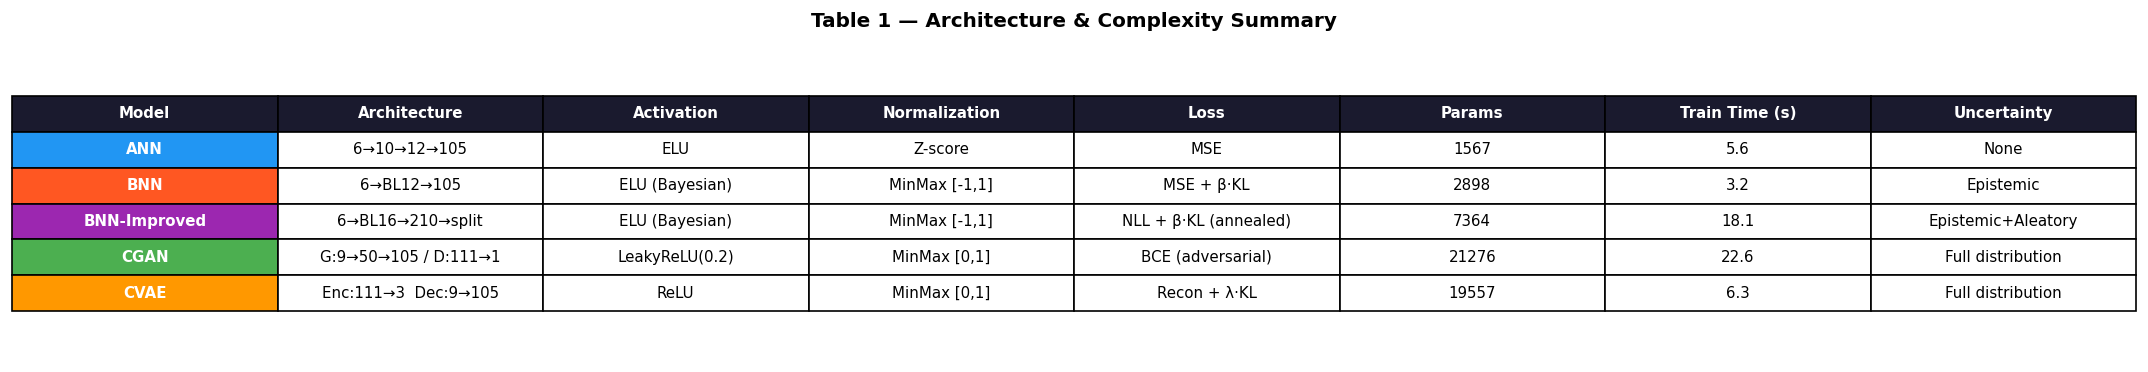

       Model         Architecture     Activation Normalization                  Loss  Params Train Time (s)        Uncertainty
         ANN          6→10→12→105            ELU       Z-score                   MSE    1567            5.6               None
         BNN           6→BL12→105 ELU (Bayesian) MinMax [-1,1]            MSE + β·KL    2898            3.2          Epistemic
BNN-Improved     6→BL16→210→split ELU (Bayesian) MinMax [-1,1] NLL + β·KL (annealed)    7364           18.1 Epistemic+Aleatory
        CGAN G:9→50→105 / D:111→1 LeakyReLU(0.2)  MinMax [0,1]     BCE (adversarial)   21276           22.6  Full distribution
        CVAE Enc:111→3  Dec:9→105           ReLU  MinMax [0,1]          Recon + λ·KL   19557            6.3  Full distribution


In [18]:
# ══════════════════════════════════════════════════════════════════
#  Fig 1  —  Architecture & Complexity Summary Table
# ══════════════════════════════════════════════════════════════════
arch_data = {
    'Model'         : ['ANN','BNN','BNN-Improved','CGAN','CVAE'],
    'Architecture'  : ['6→10→12→105','6→BL12→105','6→BL16→210→split','G:9→50→105 / D:111→1','Enc:111→3  Dec:9→105'],
    'Activation'    : ['ELU','ELU (Bayesian)','ELU (Bayesian)','LeakyReLU(0.2)','ReLU'],
    'Normalization' : ['Z-score','MinMax [-1,1]','MinMax [-1,1]','MinMax [0,1]','MinMax [0,1]'],
    'Loss'          : ['MSE','MSE + β·KL','NLL + β·KL (annealed)','BCE (adversarial)','Recon + λ·KL'],
    'Params'        : [
        ann_model.count_params(),
        bnn_model.count_params(),
        bnnx_model.count_params(),
        cgan_gen.count_params()+cgan_disc.count_params(),
        cvae_model.count_params()+cvae_ann.count_params(),
    ],
    'Train Time (s)': [f'{ANN_TIME:.1f}',f'{BNN_TIME:.1f}',f'{BNNX_TIME:.1f}',f'{CGAN_TIME:.1f}',f'{CVAE_TIME:.1f}'],
    'Uncertainty'   : ['None','Epistemic','Epistemic+Aleatory','Full distribution','Full distribution'],
}
df_arch = pd.DataFrame(arch_data)

fig, ax = plt.subplots(figsize=(18, 3.2))
ax.axis('off')
tbl = ax.table(
    cellText=df_arch.values,
    colLabels=df_arch.columns,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.7)
for j in range(len(df_arch.columns)):
    tbl[0,j].set_facecolor('#1a1a2e')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i, name in enumerate(df_arch['Model']):
    tbl[i+1,0].set_facecolor(MODEL_COLORS[name])
    tbl[i+1,0].set_text_props(color='white', fontweight='bold')
plt.title('Table 1 — Architecture & Complexity Summary', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_comparison/fig1_architecture_summary.png'); plt.show()
print(df_arch.to_string(index=False))


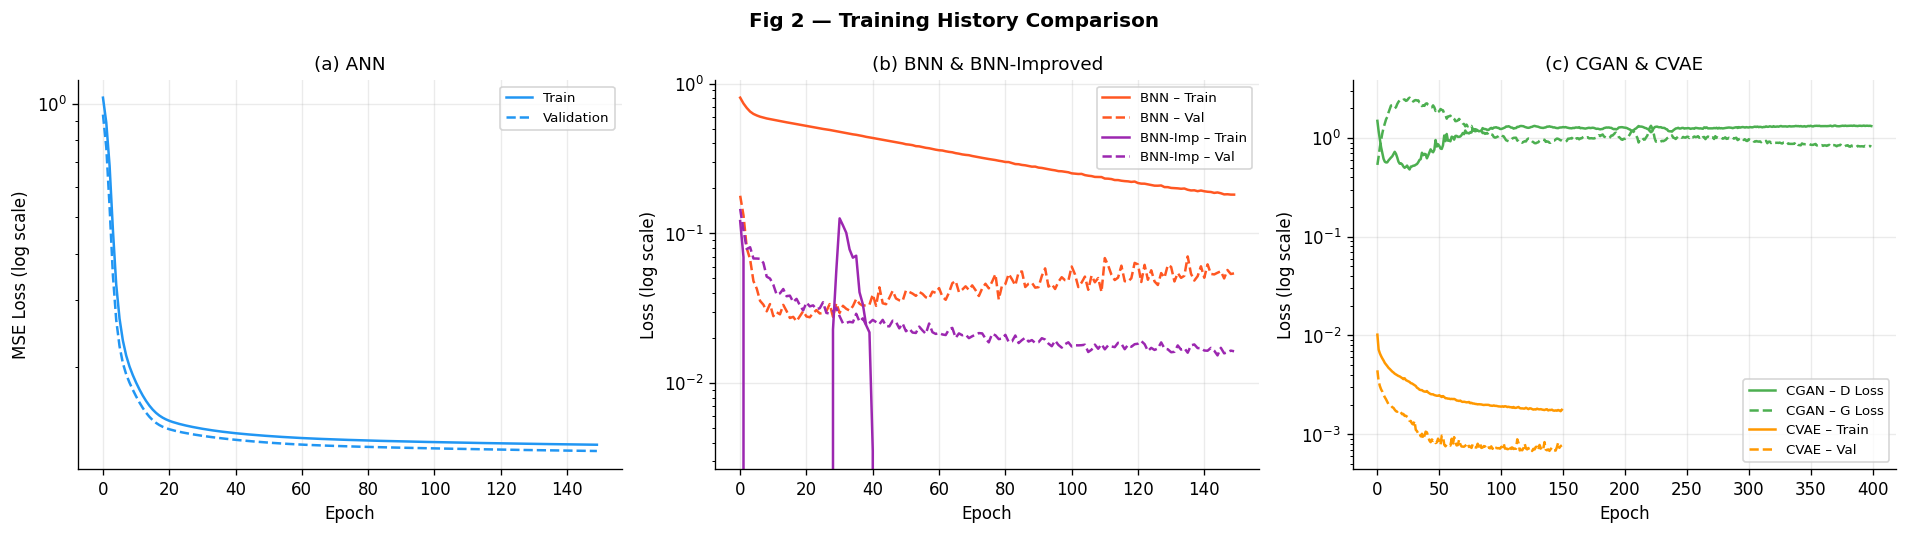

In [19]:
# ══════════════════════════════════════════════════════════════════
#  Fig 2  —  Training Loss History
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── (a) ANN
ax = axes[0]
ax.semilogy(ann_hist.history['loss'],     color=MODEL_COLORS['ANN'], lw=1.5, label='Train')
ax.semilogy(ann_hist.history['val_loss'], color=MODEL_COLORS['ANN'], lw=1.5, ls='--', label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (log scale)'); ax.set_title('(a) ANN')
ax.legend(fontsize=8)

# ── (b) BNN & BNN-Improved
ax = axes[1]
ax.semilogy(bnn_train_losses,  color=MODEL_COLORS['BNN'], lw=1.5, label='BNN – Train')
ax.semilogy(bnn_val_losses,    color=MODEL_COLORS['BNN'], lw=1.5, ls='--', label='BNN – Val')
ax.semilogy(bnnx_train_losses, color=MODEL_COLORS['BNN-Improved'], lw=1.5, label='BNN-Imp – Train')
ax.semilogy(bnnx_val_losses,   color=MODEL_COLORS['BNN-Improved'], lw=1.5, ls='--', label='BNN-Imp – Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)'); ax.set_title('(b) BNN & BNN-Improved')
ax.legend(fontsize=8)

# ── (c) CGAN & CVAE
ax = axes[2]
ax.semilogy(cgan_d_losses, color=MODEL_COLORS['CGAN'], lw=1.5, ls='-',  label='CGAN – D Loss')
ax.semilogy(cgan_g_losses, color=MODEL_COLORS['CGAN'], lw=1.5, ls='--', label='CGAN – G Loss')
ax.semilogy(cvae_losses,   color=MODEL_COLORS['CVAE'], lw=1.5, ls='-',  label='CVAE – Train')
ax.semilogy(cvae_val_losses,color=MODEL_COLORS['CVAE'],lw=1.5, ls='--', label='CVAE – Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)'); ax.set_title('(c) CGAN & CVAE')
ax.legend(fontsize=8)

fig.suptitle('Fig 2 — Training History Comparison', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures_comparison/fig2_training_history.png'); plt.show()


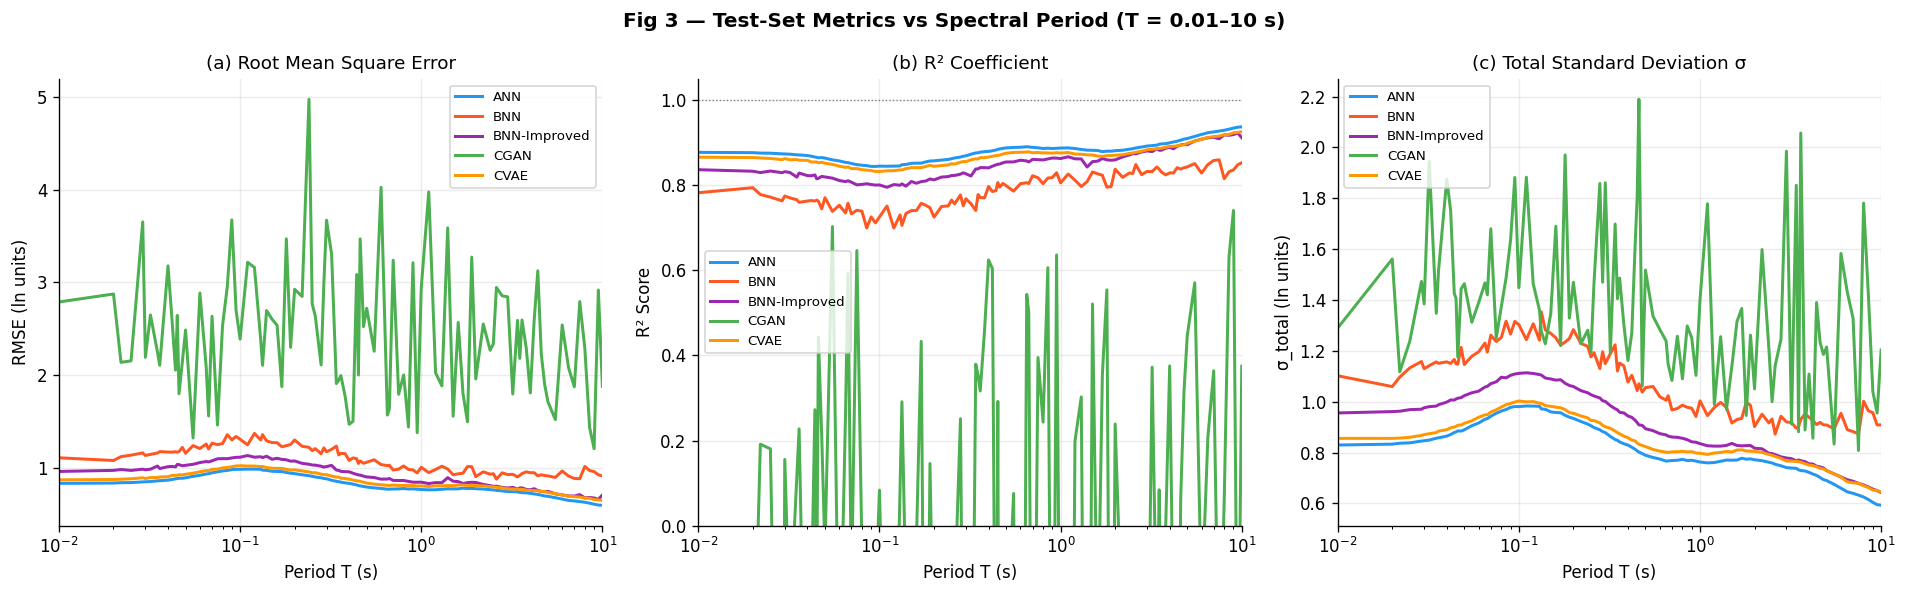


── RMSE at Key Periods ──
Model            T= 0.1s  T= 0.2s  T= 0.5s  T= 1.0s  T= 2.0s  T= 5.0s  T=10.0s
ANN              0.9808  0.9346  0.7899  0.7631  0.7719  0.6900  0.5933
BNN              1.3053  1.2981  1.0573  1.0031  0.9027  0.9102  0.9094
BNN-Improved     1.1120  1.0713  0.8990  0.8426  0.8393  0.7435  0.7044
CGAN             2.3859  2.9236  2.7191  2.9355  1.9563  1.7121  1.8762
CVAE             1.0198  0.9758  0.8329  0.8021  0.8059  0.7312  0.6452


In [20]:
# ══════════════════════════════════════════════════════════════════
#  Fig 3  —  Test-Set Performance Metrics vs Spectral Period
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for name, color in MODEL_COLORS.items():
    m = metrics[name]
    axes[0].semilogx(T, m['rmse'], color=color, lw=1.8, label=name)
    axes[1].semilogx(T, m['r2'],   color=color, lw=1.8, label=name)
    axes[2].semilogx(T, m['sigma'],color=color, lw=1.8, label=name)

for ax, ylabel, title in zip(axes,
    ['RMSE (ln units)', 'R² Score', 'σ_total (ln units)'],
    ['(a) Root Mean Square Error', '(b) R² Coefficient', '(c) Total Standard Deviation σ']):
    ax.set_xlabel('Period T (s)'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_xlim([0.01, 10])

axes[1].set_ylim([0, 1.05])
axes[1].axhline(1.0, color='gray', lw=0.8, ls=':')

fig.suptitle('Fig 3 — Test-Set Metrics vs Spectral Period (T = 0.01–10 s)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig3_metrics_vs_period.png'); plt.show()

# Summary table at key periods
key_T = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
key_idx = [np.argmin(np.abs(T - t)) for t in key_T]
print("\n── RMSE at Key Periods ──")
hdr = f"{'Model':15s}" + "".join(f"  T={t:4.1f}s" for t in key_T)
print(hdr)
for name in MODEL_NAMES:
    row = f"{name:15s}" + "".join(f"  {metrics[name]['rmse'][i]:.4f}" for i in key_idx)
    print(row)


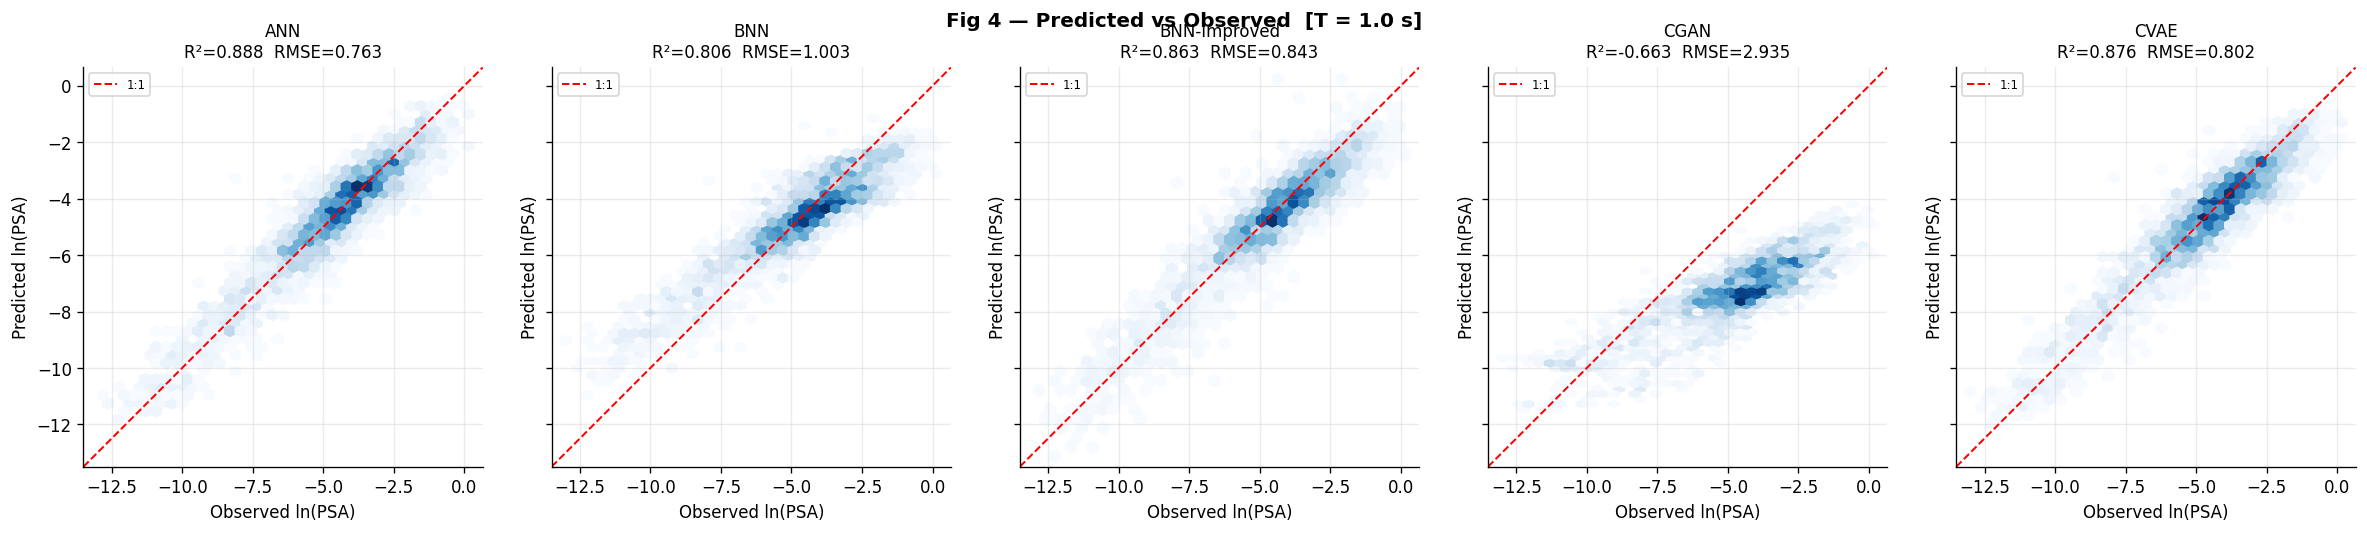

In [21]:
# ══════════════════════════════════════════════════════════════════
#  Fig 4  —  Predicted vs Observed Scatter  (T = 1.0 s)
# ══════════════════════════════════════════════════════════════════
T_PLOT = 1.0
ti = np.argmin(np.abs(T - T_PLOT))

pred_dict = {
    'ANN'         : Y_pred_ann[:, ti],
    'BNN'         : Y_pred_bnn[:, ti],
    'BNN-Improved': Y_pred_bnnx[:, ti],
    'CGAN'        : Y_pred_cgan[:, ti],
    'CVAE'        : Y_pred_cvae[:, ti],
}
obs = Y_true[:, ti]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharex=True, sharey=True)
lims = [obs.min()-0.5, obs.max()+0.5]

for ax, (name, pred) in zip(axes, pred_dict.items()):
    r2  = r2_score(obs, pred)
    rmse = np.sqrt(mean_squared_error(obs, pred))
    ax.hexbin(obs, pred, gridsize=35, cmap='Blues', mincnt=1)
    ax.plot(lims, lims, 'r--', lw=1.2, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Observed ln(PSA)'); ax.set_ylabel('Predicted ln(PSA)')
    ax.set_title(f'{name}\nR²={r2:.3f}  RMSE={rmse:.3f}', fontsize=10)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle(f'Fig 4 — Predicted vs Observed  [T = {T_PLOT} s]', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig4_predicted_vs_observed.png'); plt.show()


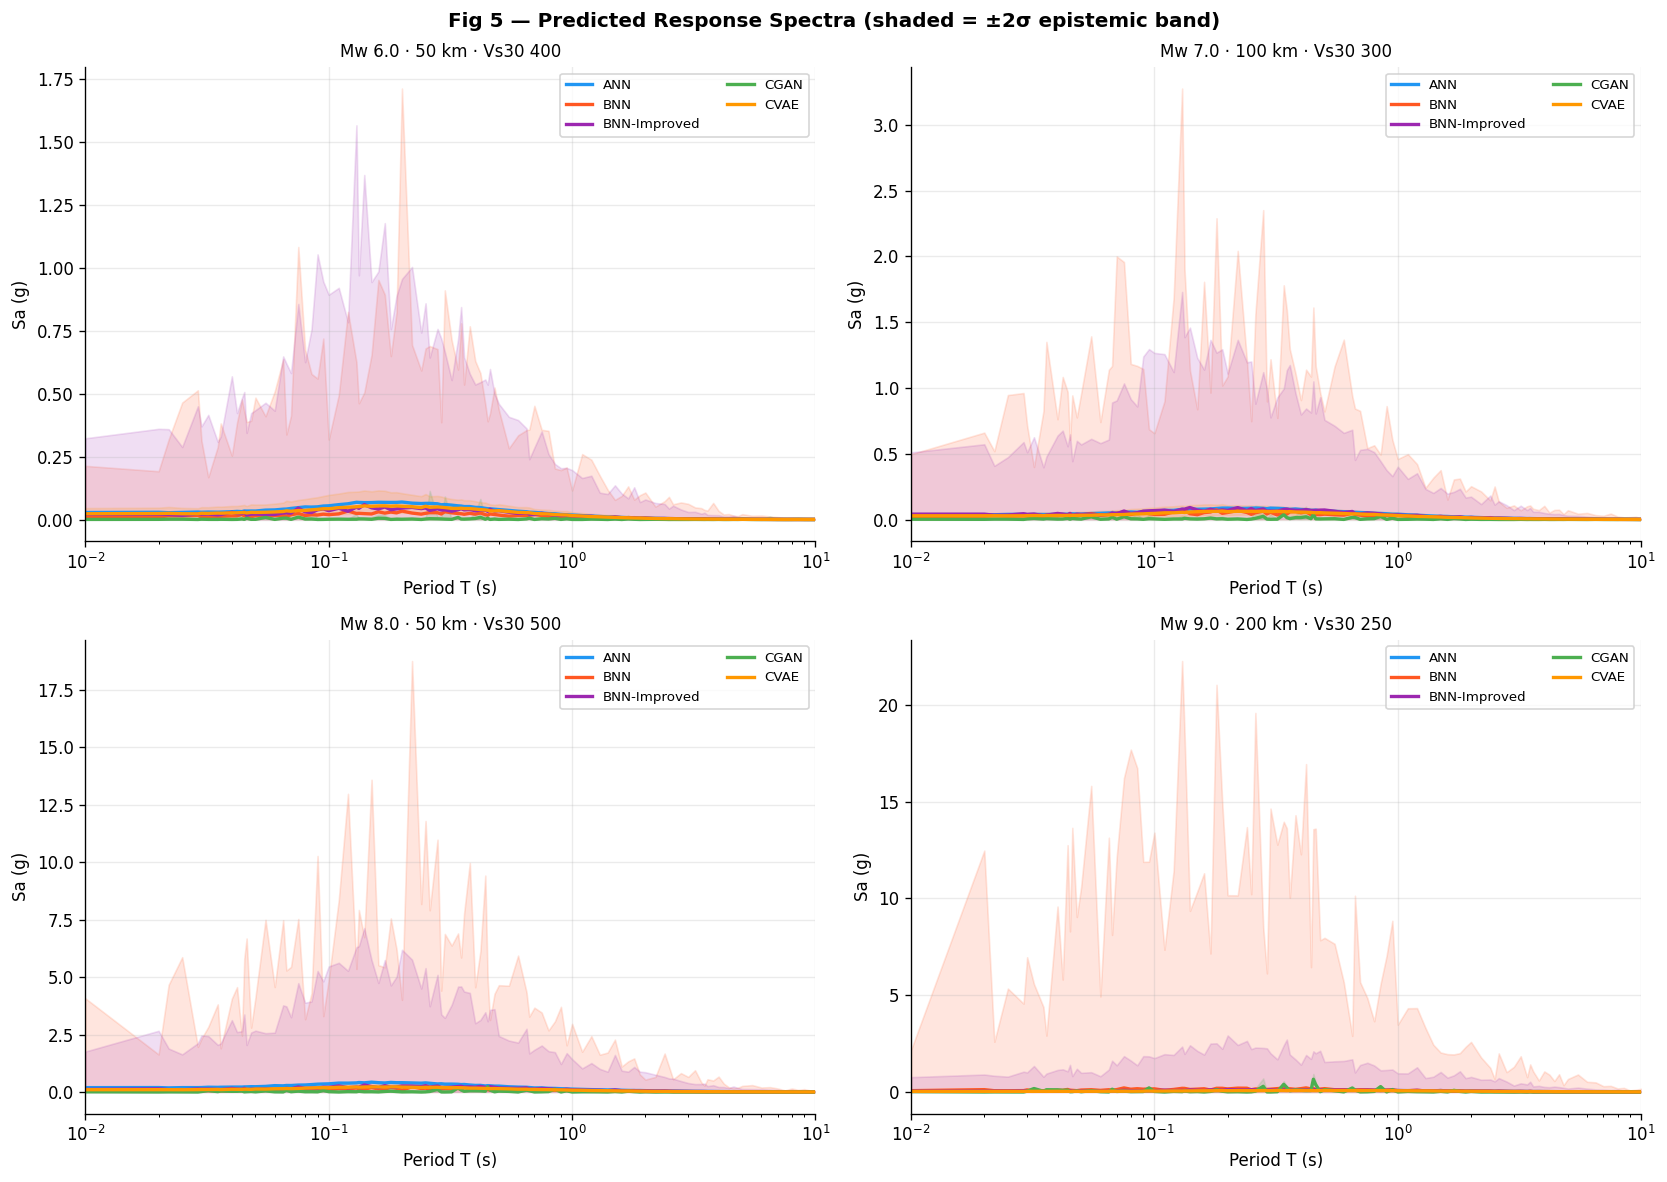

In [22]:
# ══════════════════════════════════════════════════════════════════
#  Fig 5  —  Predicted Response Spectra for Scenario Earthquakes
# ══════════════════════════════════════════════════════════════════
def make_scenario(Mw, Rjb, Vs30, depth=20, FM=1):
    """Build a single scenario input vector, return all scaled versions."""
    lrjb = np.log(max(Rjb, 0.01)); lvs30 = np.log(Vs30)
    x_raw = np.array([[Mw, Rjb, lrjb, lvs30, depth, FM]], dtype=np.float32)
    return {
        'zs': scaler_X_zs.transform(x_raw).astype(np.float32),
        'mm': scaler_X_mm.transform(x_raw).astype(np.float32),
        '01': scaler_X_01.transform(x_raw).astype(np.float32),
    }

scenarios = [
    dict(label='Mw 6.0 · 50 km · Vs30 400',  Mw=6.0, Rjb=50,  Vs30=400,  depth=20),
    dict(label='Mw 7.0 · 100 km · Vs30 300', Mw=7.0, Rjb=100, Vs30=300,  depth=30),
    dict(label='Mw 8.0 · 50 km · Vs30 500',  Mw=8.0, Rjb=50,  Vs30=500,  depth=25),
    dict(label='Mw 9.0 · 200 km · Vs30 250', Mw=9.0, Rjb=200, Vs30=250,  depth=35),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sc in zip(axes, scenarios):
    sv = make_scenario(sc['Mw'], sc['Rjb'], sc['Vs30'])
    for name, color in MODEL_COLORS.items():
        if name == 'ANN':
            mu_ln = predict_ann(sv['zs'])[0]
            ax.semilogx(T, np.exp(mu_ln), color=color, lw=2, label=name)
        elif name == 'BNN':
            mu_ln, ep_ln = predict_bnn_mean(sv['mm'])
            mu_ln = mu_ln[0]; ep_ln = ep_ln[0]
            ax.semilogx(T, np.exp(mu_ln), color=color, lw=2, label=name)
            ax.fill_between(T, np.exp(mu_ln-2*ep_ln), np.exp(mu_ln+2*ep_ln),
                            color=color, alpha=0.15)
        elif name == 'BNN-Improved':
            mu_ln, ep_ln, al_ln = predict_bnnx_mean(sv['mm'])
            mu_ln = mu_ln[0]; ep_ln = ep_ln[0]; al_ln = al_ln[0]
            sig_tot = np.sqrt(ep_ln**2 + al_ln**2)
            ax.semilogx(T, np.exp(mu_ln), color=color, lw=2, label=name)
            ax.fill_between(T, np.exp(mu_ln-2*sig_tot), np.exp(mu_ln+2*sig_tot),
                            color=color, alpha=0.15)
        elif name == 'CGAN':
            ens = predict_cgan_ensemble(sv['01'], n_gen=N_GEN)[:,0,:]  # (n_gen, 105)
            mu_ln = ens.mean(0); ep_ln = ens.std(0)
            ax.semilogx(T, np.exp(mu_ln), color=color, lw=2, label=name)
            ax.fill_between(T, np.exp(mu_ln-2*ep_ln), np.exp(mu_ln+2*ep_ln),
                            color=color, alpha=0.15)
        elif name == 'CVAE':
            ens = predict_cvae_ensemble(sv['01'], n_gen=N_GEN)[:,0,:]
            mu_ln = ens.mean(0); ep_ln = ens.std(0)
            ax.semilogx(T, np.exp(mu_ln), color=color, lw=2, label=name)
            ax.fill_between(T, np.exp(mu_ln-2*ep_ln), np.exp(mu_ln+2*ep_ln),
                            color=color, alpha=0.15)

    ax.set_xlabel('Period T (s)'); ax.set_ylabel('Sa (g)')
    ax.set_title(sc['label'], fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    ax.set_xlim([0.01, 10])

fig.suptitle('Fig 5 — Predicted Response Spectra (shaded = ±2σ epistemic band)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures_comparison/fig5_response_spectra_scenarios.png'); plt.show()


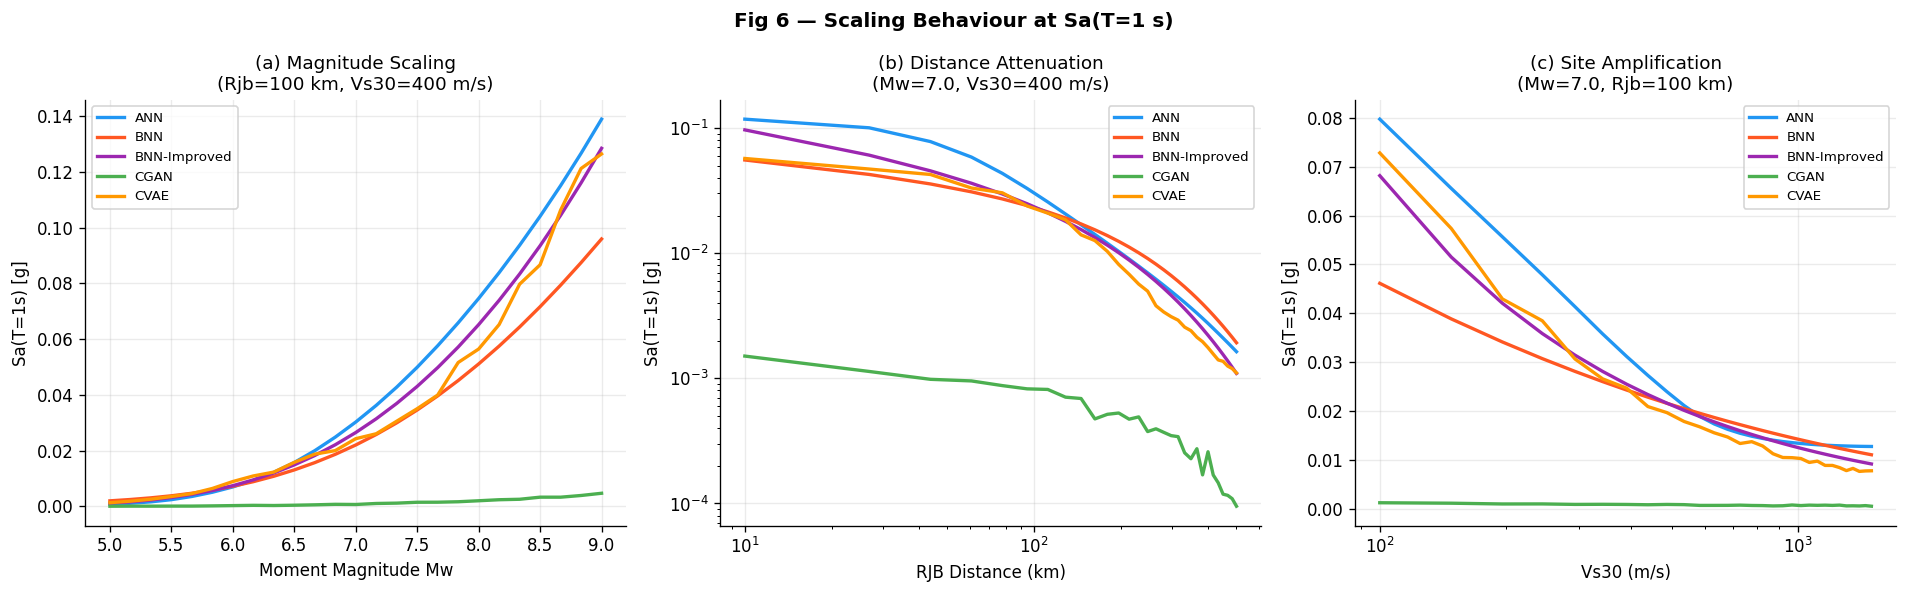

In [23]:
# ══════════════════════════════════════════════════════════════════
#  Fig 6  —  Scaling Behaviour  (Sa at T=1 s)
#  Panel (a): Magnitude scaling  (fixed Rjb=100, Vs30=400, depth=20)
#  Panel (b): Distance scaling   (fixed Mw=7.0, Vs30=400, depth=20)
#  Panel (c): Vs30 scaling       (fixed Mw=7.0, Rjb=100,  depth=20)
# ══════════════════════════════════════════════════════════════════
ti = np.argmin(np.abs(T - 1.0))

def sa_t1_predict(name, X_zs, X_mm, X_01):
    if name=='ANN':          return predict_ann(X_zs)[:,ti]
    if name=='BNN':          return predict_bnn_mean(X_mm)[0][:,ti]
    if name=='BNN-Improved': return predict_bnnx_mean(X_mm)[0][:,ti]
    if name=='CGAN':         return predict_cgan_ensemble(X_01, n_gen=50).mean(0)[:,ti]
    if name=='CVAE':         return predict_cvae_ensemble(X_01, n_gen=50).mean(0)[:,ti]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Magnitude scaling
Mw_vals = np.linspace(5.0, 9.0, 25)
for name, color in MODEL_COLORS.items():
    xr = np.column_stack([Mw_vals, np.full(25,100), np.log(100)*np.ones(25),
                          np.log(400)*np.ones(25), np.full(25,20), np.ones(25)]).astype(np.float32)
    sa = sa_t1_predict(name, scaler_X_zs.transform(xr), scaler_X_mm.transform(xr), scaler_X_01.transform(xr))
    axes[0].plot(Mw_vals, np.exp(sa), color=color, lw=2, label=name)
axes[0].set_xlabel('Moment Magnitude Mw'); axes[0].set_ylabel('Sa(T=1s) [g]')
axes[0].set_title('(a) Magnitude Scaling\n(Rjb=100 km, Vs30=400 m/s)'); axes[0].legend(fontsize=8)

# (b) Distance scaling
Rjb_vals = np.linspace(10, 500, 30)
for name, color in MODEL_COLORS.items():
    xr = np.column_stack([np.full(30,7.0), Rjb_vals, np.log(Rjb_vals),
                          np.log(400)*np.ones(30), np.full(30,20), np.ones(30)]).astype(np.float32)
    sa = sa_t1_predict(name, scaler_X_zs.transform(xr), scaler_X_mm.transform(xr), scaler_X_01.transform(xr))
    axes[1].loglog(Rjb_vals, np.exp(sa), color=color, lw=2, label=name)
axes[1].set_xlabel('RJB Distance (km)'); axes[1].set_ylabel('Sa(T=1s) [g]')
axes[1].set_title('(b) Distance Attenuation\n(Mw=7.0, Vs30=400 m/s)'); axes[1].legend(fontsize=8)

# (c) Vs30 scaling
Vs30_vals = np.linspace(100, 1500, 30)
for name, color in MODEL_COLORS.items():
    xr = np.column_stack([np.full(30,7.0), np.full(30,100), np.log(100)*np.ones(30),
                          np.log(Vs30_vals), np.full(30,20), np.ones(30)]).astype(np.float32)
    sa = sa_t1_predict(name, scaler_X_zs.transform(xr), scaler_X_mm.transform(xr), scaler_X_01.transform(xr))
    axes[2].semilogx(Vs30_vals, np.exp(sa), color=color, lw=2, label=name)
axes[2].set_xlabel('Vs30 (m/s)'); axes[2].set_ylabel('Sa(T=1s) [g]')
axes[2].set_title('(c) Site Amplification\n(Mw=7.0, Rjb=100 km)'); axes[2].legend(fontsize=8)

fig.suptitle('Fig 6 — Scaling Behaviour at Sa(T=1 s)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig6_scaling_behaviour.png'); plt.show()


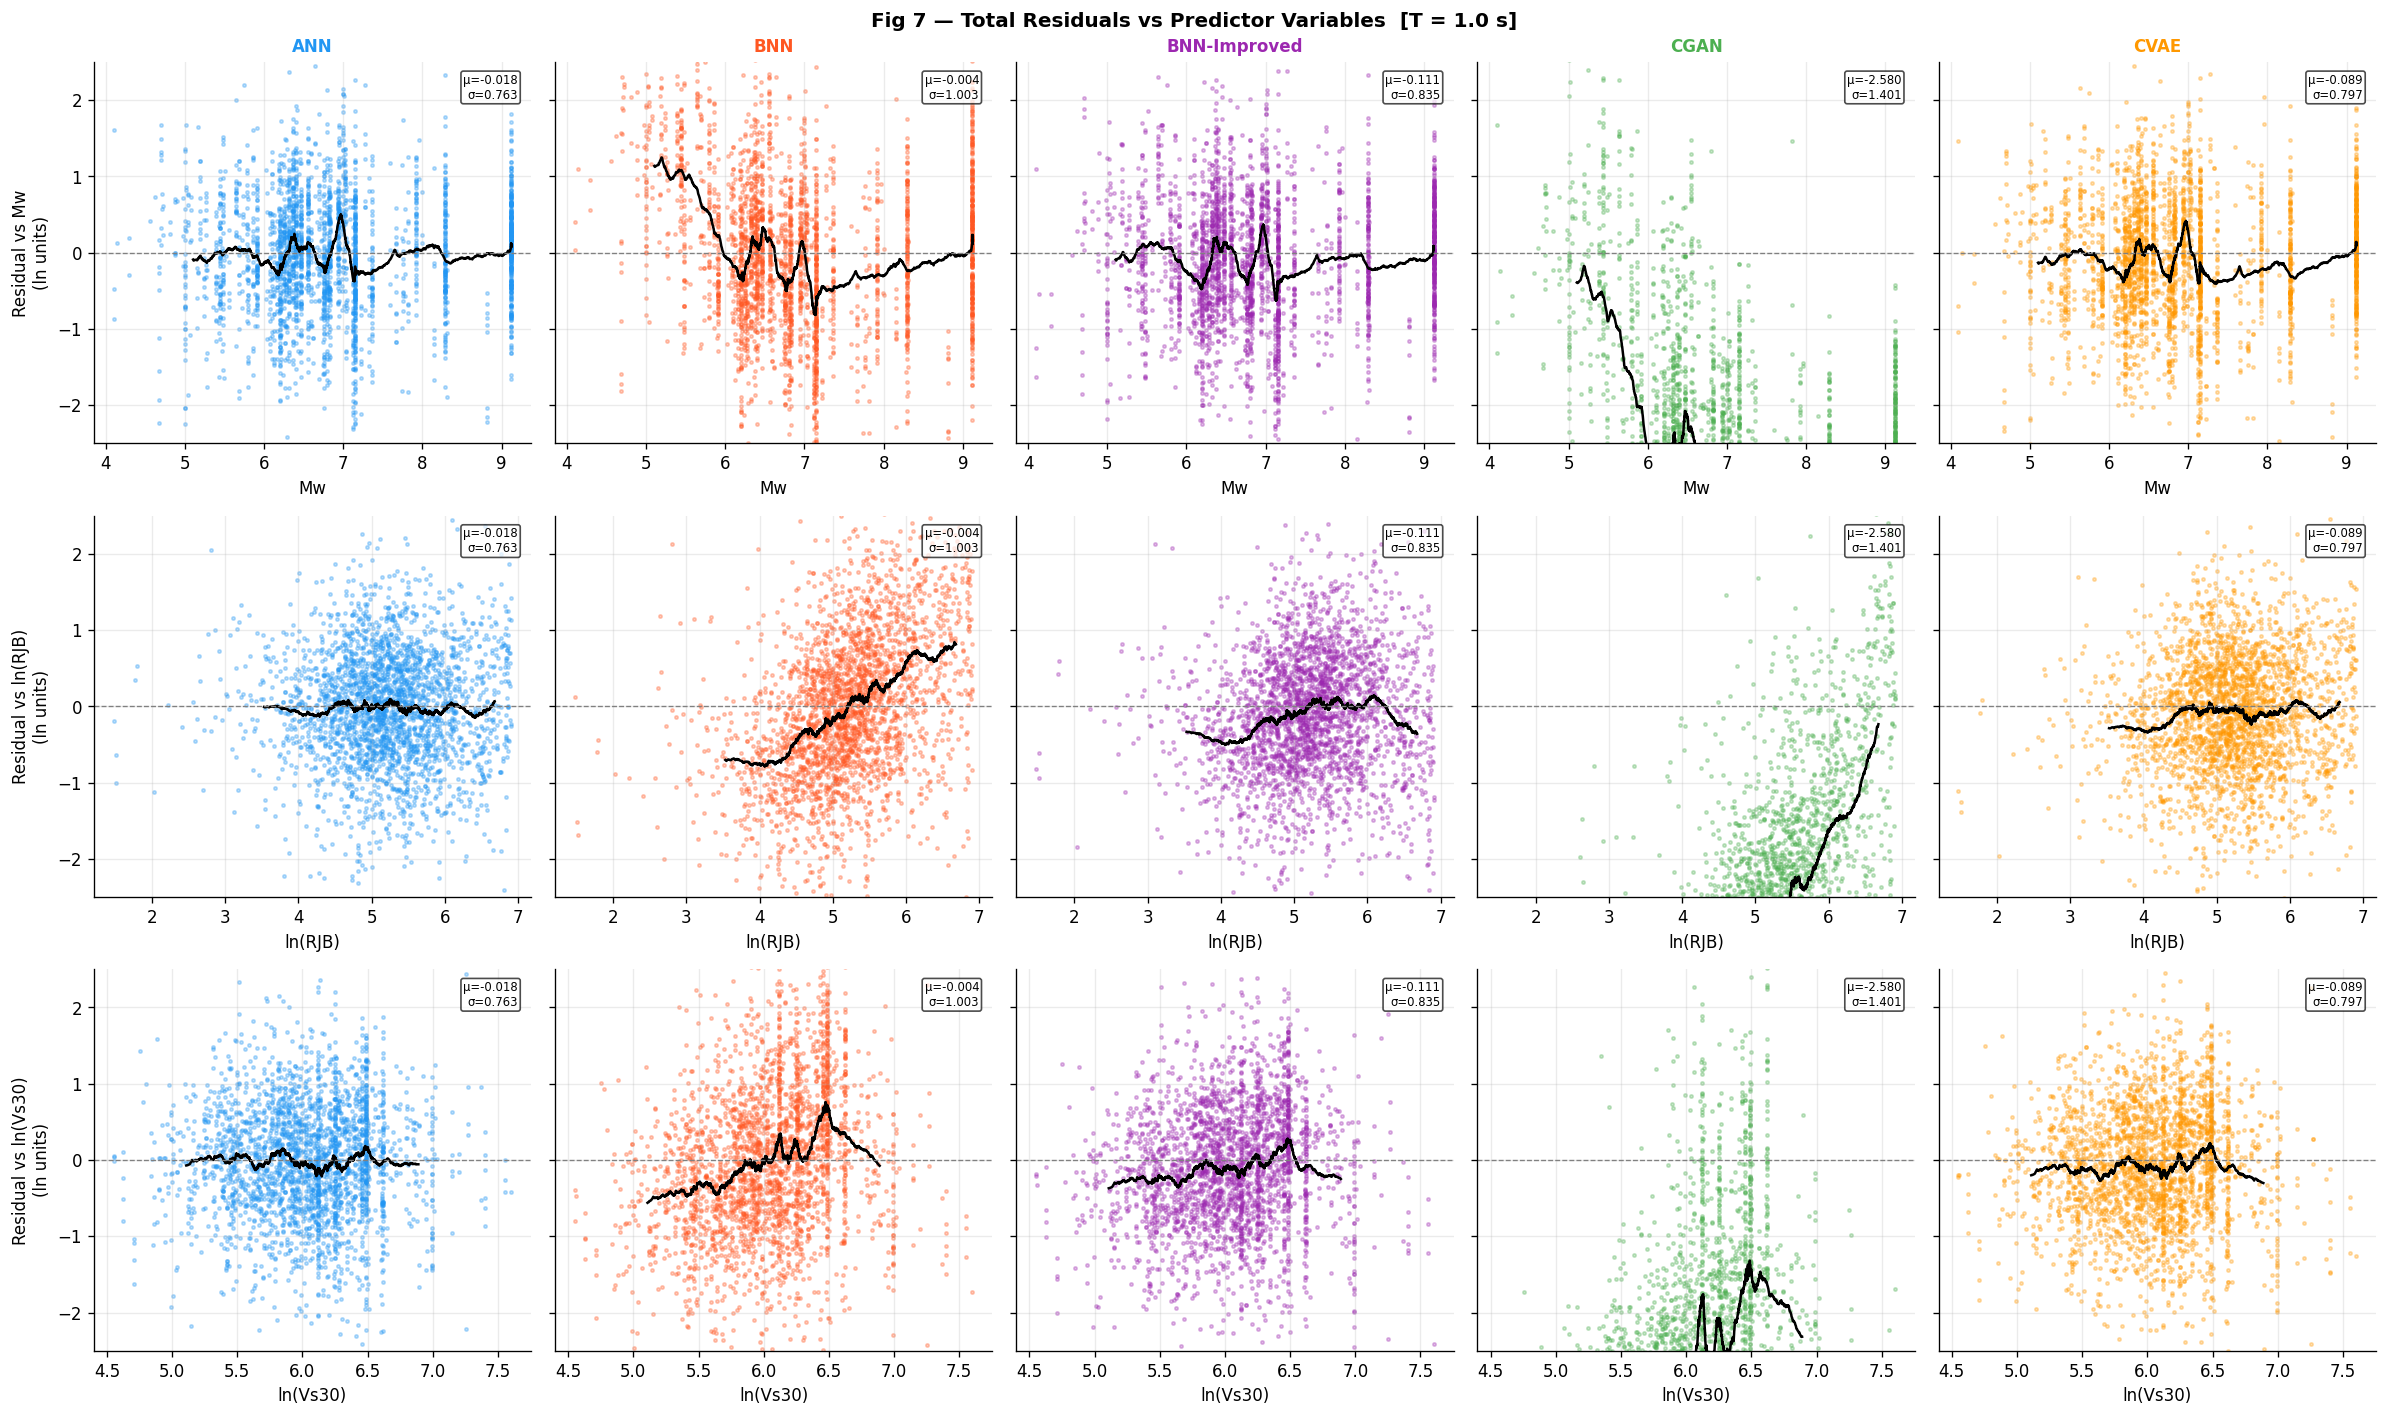

In [24]:
# ══════════════════════════════════════════════════════════════════
#  Fig 7  —  Total Residuals vs Predictor Variables  (T = 1.0 s)
#  Panels: vs Mw | vs ln(Rjb) | vs ln(Vs30)
# ══════════════════════════════════════════════════════════════════
ti = np.argmin(np.abs(T - 1.0))
te_mw   = MW_V[idx_te]
te_rjb  = RJB_V[idx_te]
te_vs30 = VS30_V[idx_te]

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)

predictors = [
    (te_mw,         'Mw',           False),
    (np.log(te_rjb),'ln(RJB)',      False),
    (np.log(te_vs30),'ln(Vs30)',    False),
]

for col, (name, color) in enumerate(MODEL_COLORS.items()):
    r1 = res[name][:, ti]
    for row, (xvar, xlabel, logx) in enumerate(predictors):
        ax = axes[row, col]
        ax.scatter(xvar, r1, s=4, alpha=0.3, color=color, rasterized=True)
        # smoothed running mean
        order = np.argsort(xvar)
        from numpy.lib.stride_tricks import sliding_window_view
        win = max(len(xvar)//15, 10)
        xs = xvar[order]; rs = r1[order]
        xs_sm = np.convolve(xs, np.ones(win)/win, 'valid')
        rs_sm = np.convolve(rs, np.ones(win)/win, 'valid')
        ax.plot(xs_sm, rs_sm, 'k-', lw=1.5, label='Trend')
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylim([-2.5, 2.5])
        if row == 0: ax.set_title(name, fontsize=10, color=color, fontweight='bold')
        if col == 0: ax.set_ylabel(f'Residual vs {xlabel}\n(ln units)')
        ax.set_xlabel(xlabel)
        # bias annotation
        ax.text(0.97, 0.97, f'μ={r1.mean():.3f}\nσ={r1.std():.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=7,
                bbox=dict(fc='white', alpha=0.7, boxstyle='round,pad=0.2'))

fig.suptitle('Fig 7 — Total Residuals vs Predictor Variables  [T = 1.0 s]', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig7_residuals_vs_predictors.png', dpi=120); plt.show()


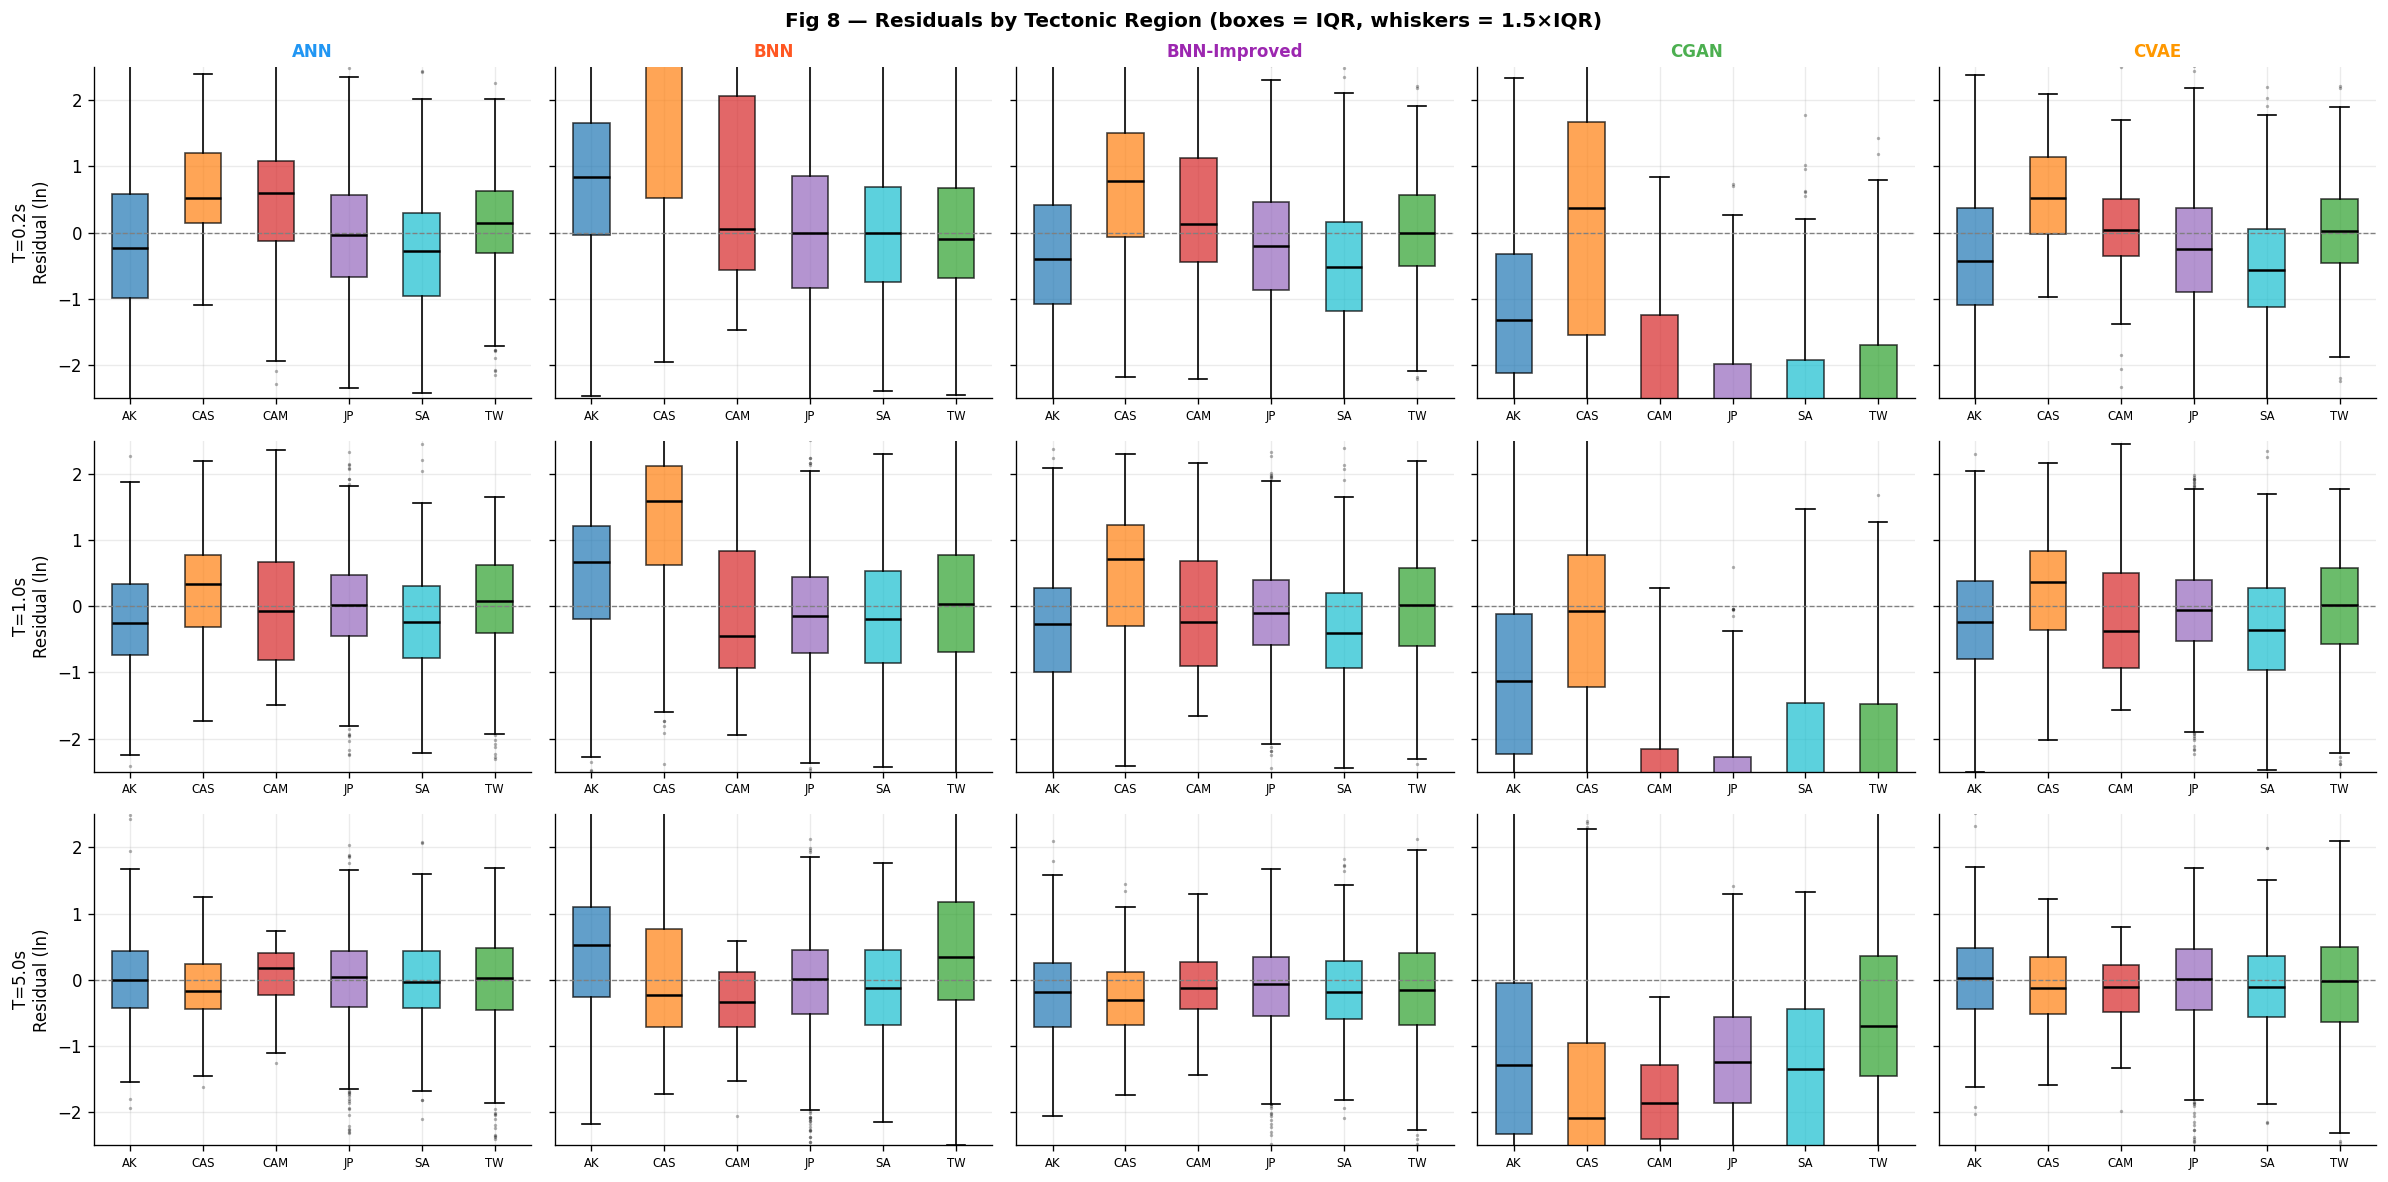

In [25]:
# ══════════════════════════════════════════════════════════════════
#  Fig 8  —  Residuals by Tectonic Region  (T = 0.2, 1.0, 5.0 s)
# ══════════════════════════════════════════════════════════════════
plot_periods = [0.2, 1.0, 5.0]
te_rg = RG_IDS[idx_te]
region_labels = [REGION_NAMES[r] for r in sorted(REGION_NAMES.keys())]
region_vals   = sorted(REGION_NAMES.keys())

fig, axes = plt.subplots(len(plot_periods), 5, figsize=(20, 10), sharey=True)

for col, (name, color) in enumerate(MODEL_COLORS.items()):
    for row, tp in enumerate(plot_periods):
        ti = np.argmin(np.abs(T - tp))
        r  = res[name][:, ti]
        ax = axes[row, col]
        data_by_region = [r[te_rg == rv] for rv in region_vals]
        bp = ax.boxplot(data_by_region, labels=region_labels, patch_artist=True,
                        medianprops=dict(color='black', lw=1.5),
                        flierprops=dict(marker='.', ms=2, alpha=0.3))
        for patch, rv in zip(bp['boxes'], region_vals):
            patch.set_facecolor(REGION_COLORS[rv]); patch.set_alpha(0.7)
        ax.axhline(0, color='gray', lw=0.8, ls='--')
        ax.set_ylim([-2.5, 2.5])
        if row == 0: ax.set_title(name, fontsize=10, color=color, fontweight='bold')
        if col == 0: ax.set_ylabel(f'T={tp}s\nResidual (ln)')
        ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Fig 8 — Residuals by Tectonic Region (boxes = IQR, whiskers = 1.5×IQR)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig8_residuals_by_region.png', dpi=120); plt.show()


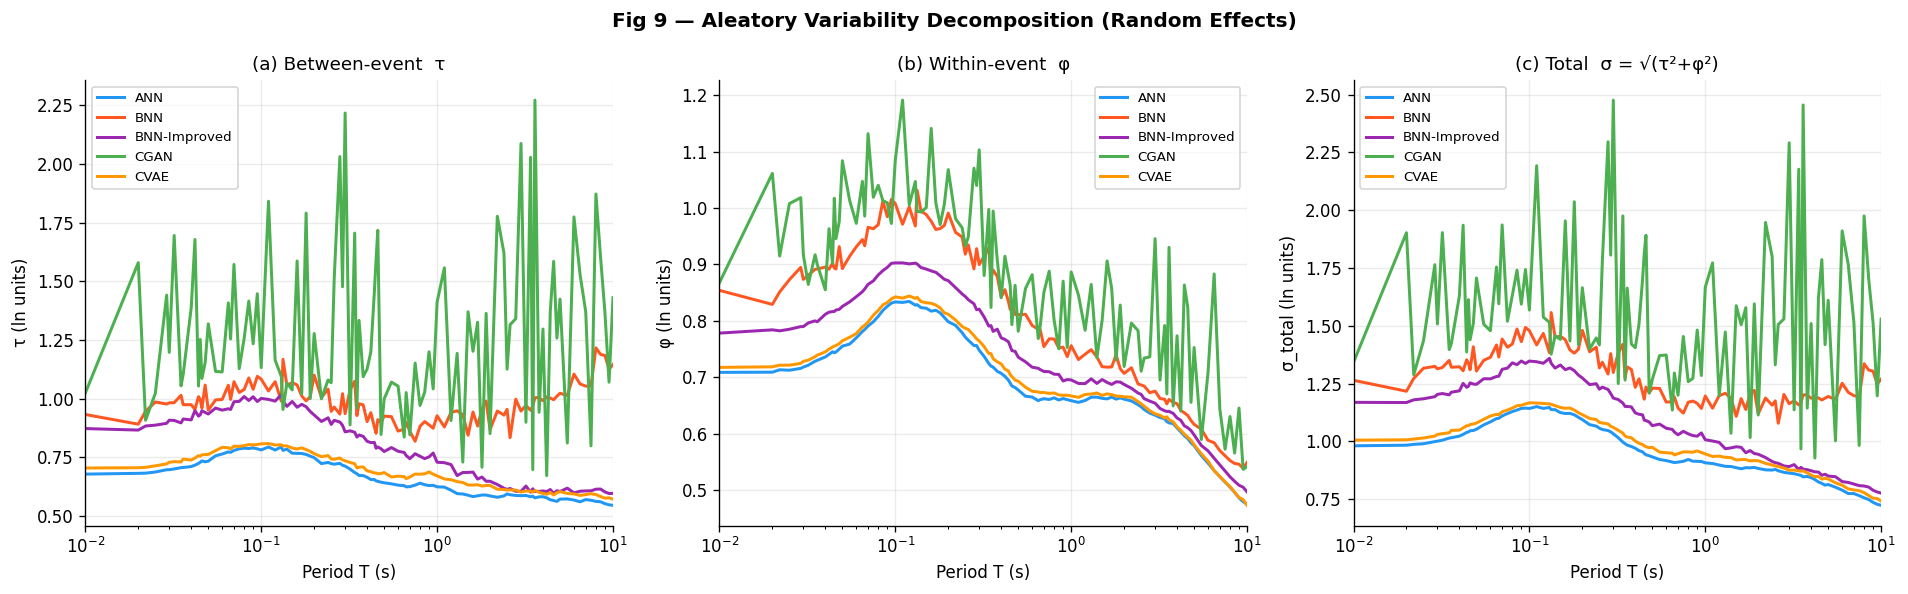

In [26]:
# ══════════════════════════════════════════════════════════════════
#  Fig 9  —  Sigma Decomposition vs Period
#  Within-event (φ) and Between-event (τ) via random-effects
# ══════════════════════════════════════════════════════════════════
def compute_mixed_effects(residuals, event_ids):
    """Simple moment-based between/within-event sigma."""
    events = np.unique(event_ids)
    ev_means = np.array([residuals[event_ids==e].mean(0) for e in events])
    tau  = ev_means.std(0)           # between-event σ
    # within-event
    wires = []
    for e in events:
        mask = event_ids == e
        wires.append(residuals[mask] - ev_means[events==e])
    phi = np.concatenate(wires, 0).std(0)  # within-event σ
    sigma = np.sqrt(tau**2 + phi**2)
    return tau, phi, sigma

te_evids = EV_IDS[idx_te]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for name, color in MODEL_COLORS.items():
    tau, phi, sigma = compute_mixed_effects(res[name], te_evids)
    axes[0].semilogx(T, tau,   color=color, lw=1.8, label=name)
    axes[1].semilogx(T, phi,   color=color, lw=1.8, label=name)
    axes[2].semilogx(T, sigma, color=color, lw=1.8, label=name)

for ax, ylabel, title in zip(axes,
    ['τ (ln units)', 'φ (ln units)', 'σ_total (ln units)'],
    ['(a) Between-event  τ', '(b) Within-event  φ', '(c) Total  σ = √(τ²+φ²)']):
    ax.set_xlabel('Period T (s)'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_xlim([0.01, 10])

fig.suptitle('Fig 9 — Aleatory Variability Decomposition (Random Effects)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig9_sigma_decomposition.png'); plt.show()


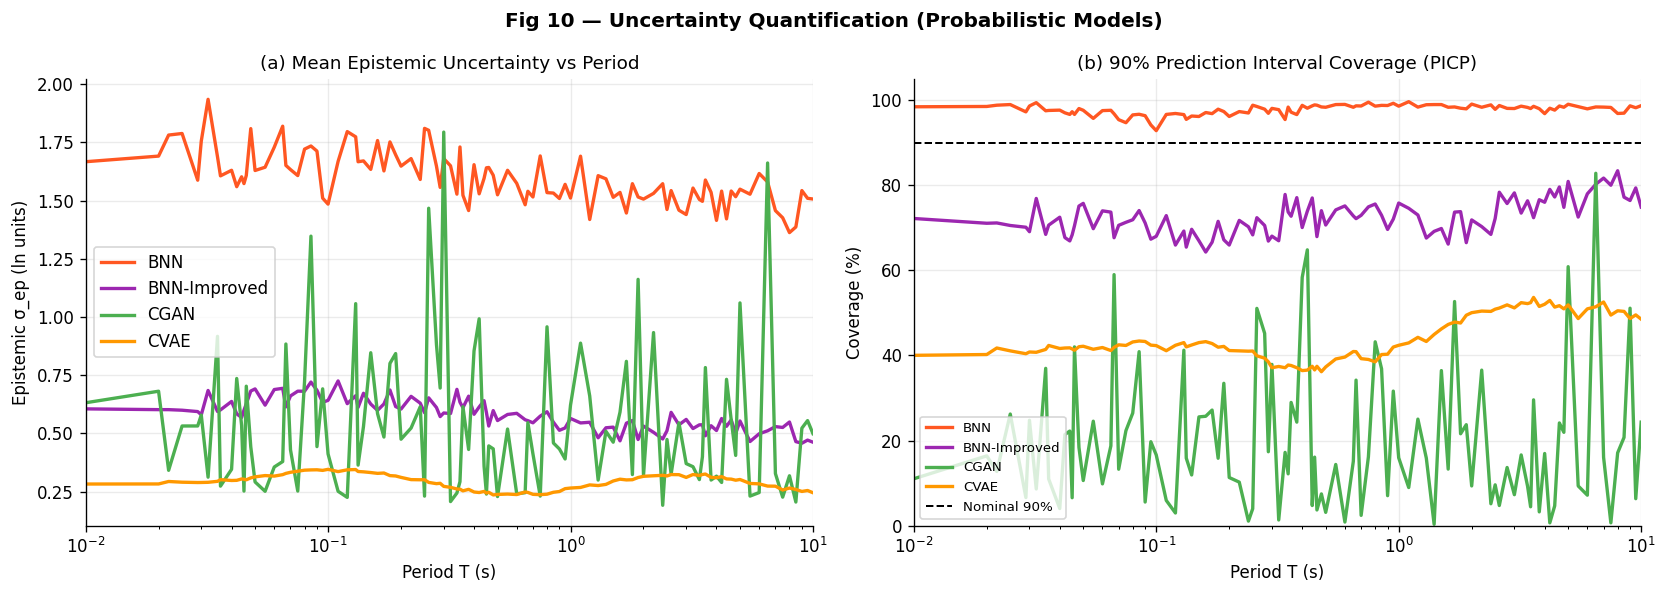


── Mean PICP (90%) across all periods ──
  BNN            : 97.8%  (ideal = 90%)
  BNN-Improved   : 72.5%  (ideal = 90%)
  CGAN           : 19.9%  (ideal = 90%)
  CVAE           : 43.8%  (ideal = 90%)


In [27]:
# ══════════════════════════════════════════════════════════════════
#  Fig 10  —  Uncertainty Quantification Comparison
#  Epistemic σ vs Period for probabilistic models
#  + Interval Coverage (90%) for one test scenario
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Epistemic σ vs period (mean over test set)
ep_dict = {
    'BNN'         : Y_ep_bnn.mean(0),
    'BNN-Improved': Y_ep_bnnx.mean(0),
    'CGAN'        : Y_ep_cgan.mean(0),
    'CVAE'        : Y_ep_cvae.mean(0),
}
ax = axes[0]
for name, ep in ep_dict.items():
    ax.semilogx(T, ep, color=MODEL_COLORS[name], lw=2, label=name)
ax.set_xlabel('Period T (s)'); ax.set_ylabel('Epistemic σ_ep (ln units)')
ax.set_title('(a) Mean Epistemic Uncertainty vs Period')
ax.legend(); ax.set_xlim([0.01, 10])

# (b) 90% Prediction Interval Coverage (PICP) vs period
ax = axes[1]
# Coverage = fraction of true values inside [μ - 1.645σ, μ + 1.645σ]
def picp(y_true, y_pred_mean, y_pred_ep, z=1.645):
    lo = y_pred_mean - z * y_pred_ep
    hi = y_pred_mean + z * y_pred_ep
    cov = ((y_true >= lo) & (y_true <= hi)).mean(0)
    return cov

picp_dict = {
    'BNN'         : picp(Y_true, Y_pred_bnn,  Y_ep_bnn),
    'BNN-Improved': picp(Y_true, Y_pred_bnnx, Y_ep_bnnx),
    'CGAN'        : picp(Y_true, Y_pred_cgan, Y_ep_cgan),
    'CVAE'        : picp(Y_true, Y_pred_cvae, Y_ep_cvae),
}
for name, cov in picp_dict.items():
    ax.semilogx(T, cov * 100, color=MODEL_COLORS[name], lw=2, label=name)
ax.axhline(90, color='black', lw=1.2, ls='--', label='Nominal 90%')
ax.set_xlabel('Period T (s)'); ax.set_ylabel('Coverage (%)')
ax.set_title('(b) 90% Prediction Interval Coverage (PICP)')
ax.legend(fontsize=8); ax.set_xlim([0.01, 10])
ax.set_ylim([0, 105])

fig.suptitle('Fig 10 — Uncertainty Quantification (Probabilistic Models)', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig10_uncertainty_quantification.png'); plt.show()

# Table of mean PICP
print("\n── Mean PICP (90%) across all periods ──")
for name, cov in picp_dict.items():
    print(f"  {name:15s}: {cov.mean()*100:.1f}%  (ideal = 90%)")


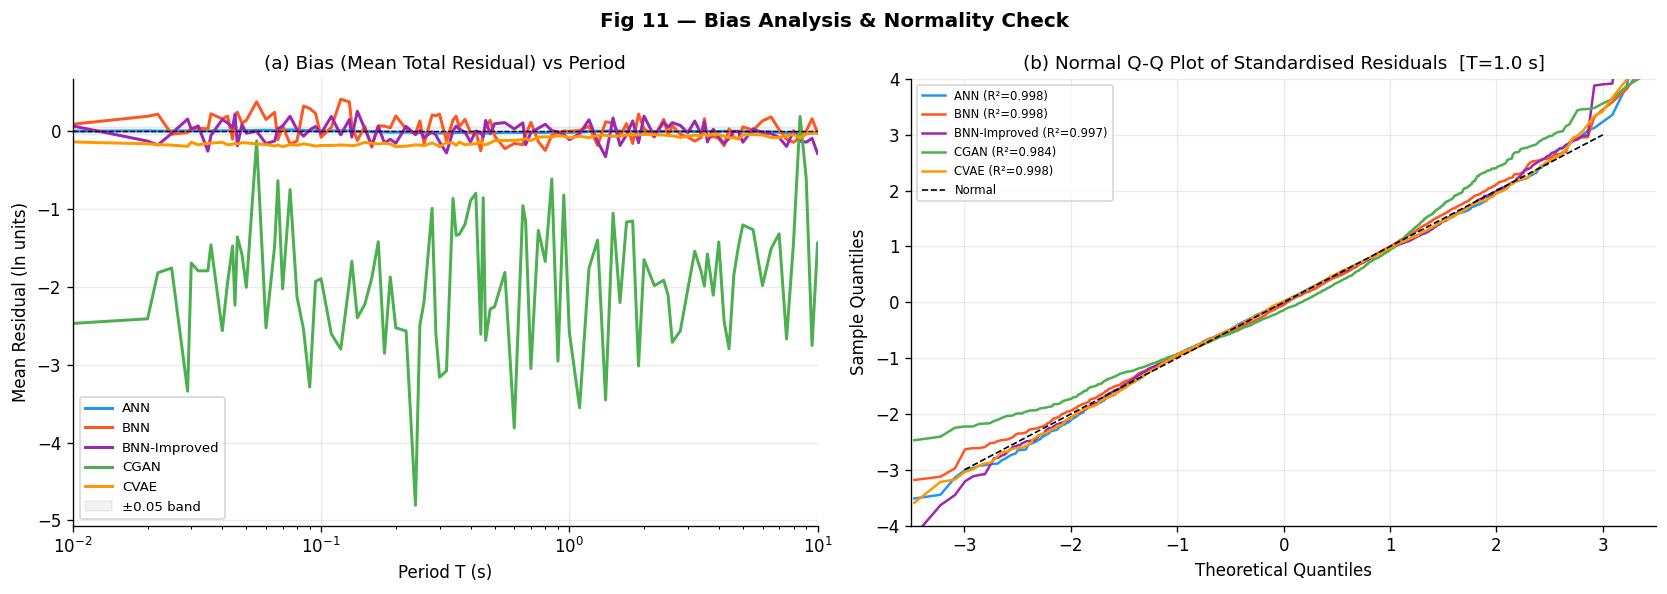

In [28]:
# ══════════════════════════════════════════════════════════════════
#  Fig 11  —  Bias (Mean Residual) vs Period + Tail-end Analysis
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, color in MODEL_COLORS.items():
    ax.semilogx(T, metrics[name]['bias'], color=color, lw=1.8, label=name)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(T, -0.05, 0.05, alpha=0.1, color='gray', label='±0.05 band')
ax.set_xlabel('Period T (s)'); ax.set_ylabel('Mean Residual (ln units)')
ax.set_title('(a) Bias (Mean Total Residual) vs Period')
ax.legend(fontsize=8); ax.set_xlim([0.01, 10])

# (b) Q-Q plot residuals at T=1.0 s
ax = axes[1]
ti = np.argmin(np.abs(T - 1.0))
for name, color in MODEL_COLORS.items():
    r = res[name][:, ti]
    r_std = (r - r.mean()) / r.std()
    (osm, osr), (slope, intercept, r2) = stats.probplot(r_std)
    ax.plot(osm, osr, color=color, lw=1.5, label=f'{name} (R²={r2:.3f})')
ax.plot([-3,3],[-3,3], 'k--', lw=1, label='Normal')
ax.set_xlim([-3.5, 3.5]); ax.set_ylim([-4, 4])
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('(b) Normal Q-Q Plot of Standardised Residuals  [T=1.0 s]')
ax.legend(fontsize=7)

fig.suptitle('Fig 11 — Bias Analysis & Normality Check', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig11_bias_qqplot.png'); plt.show()


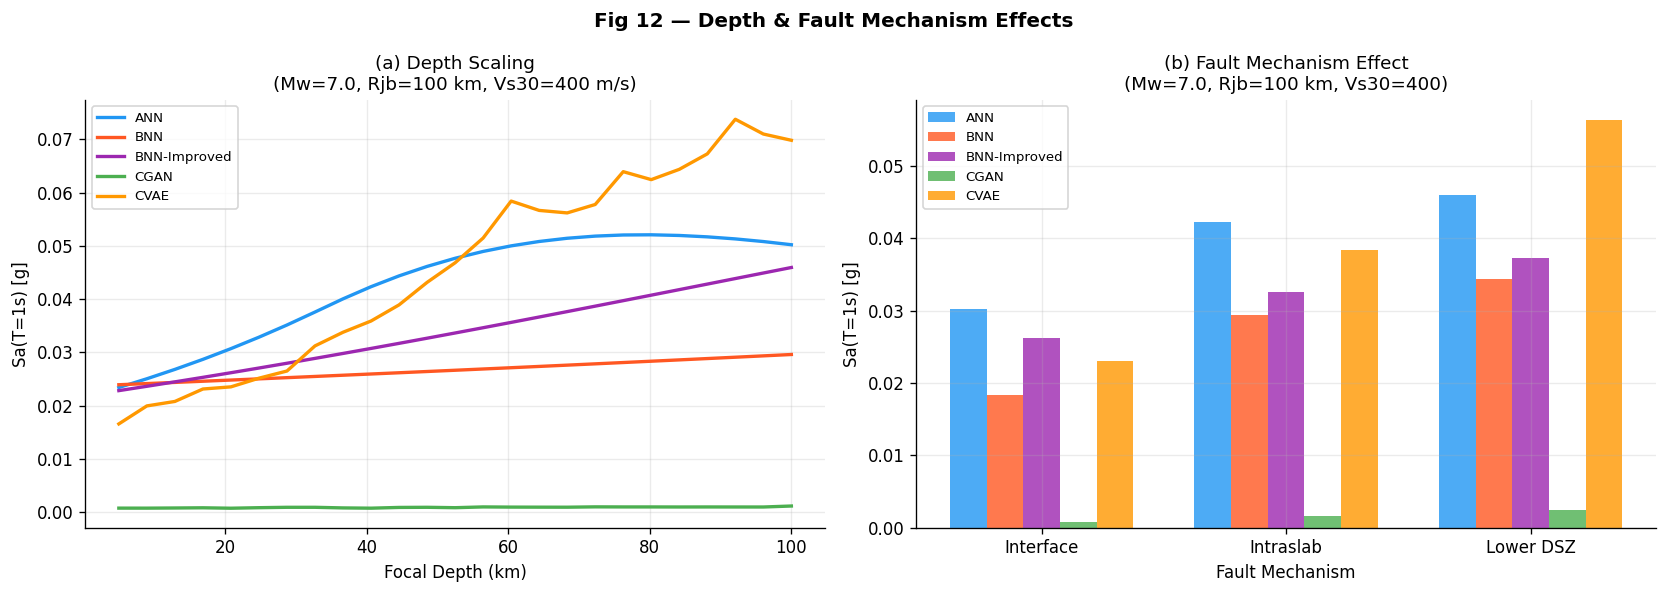

In [29]:
# ══════════════════════════════════════════════════════════════════
#  Fig 12  —  Depth Scaling & Fault Mechanism Effect  (T=1 s)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Depth scaling
depths = np.linspace(5, 100, 25)
for name, color in MODEL_COLORS.items():
    xr = np.column_stack([np.full(25,7.0), np.full(25,100), np.log(100)*np.ones(25),
                          np.log(400)*np.ones(25), depths, np.ones(25)]).astype(np.float32)
    sa = sa_t1_predict(name, scaler_X_zs.transform(xr), scaler_X_mm.transform(xr), scaler_X_01.transform(xr))
    axes[0].plot(depths, np.exp(sa), color=color, lw=2, label=name)
axes[0].set_xlabel('Focal Depth (km)'); axes[0].set_ylabel('Sa(T=1s) [g]')
axes[0].set_title('(a) Depth Scaling\n(Mw=7.0, Rjb=100 km, Vs30=400 m/s)'); axes[0].legend(fontsize=8)

# (b) Fault mechanism comparison
fm_vals   = [1, 2, 3]
fm_labels = ['Interface', 'Intraslab', 'Lower DSZ']
x_pos = np.arange(len(fm_vals))
width = 0.15
for j, (name, color) in enumerate(MODEL_COLORS.items()):
    sa_fm = []
    for fm in fm_vals:
        xr = np.array([[7.0, 100., np.log(100), np.log(400), 20., fm]], dtype=np.float32)
        sa_s = sa_t1_predict(name, scaler_X_zs.transform(xr), scaler_X_mm.transform(xr), scaler_X_01.transform(xr))
        sa_fm.append(np.exp(sa_s[0]))
    axes[1].bar(x_pos + j*width, sa_fm, width, color=color, alpha=0.8, label=name)
axes[1].set_xticks(x_pos + 2*width); axes[1].set_xticklabels(fm_labels)
axes[1].set_xlabel('Fault Mechanism'); axes[1].set_ylabel('Sa(T=1s) [g]')
axes[1].set_title('(b) Fault Mechanism Effect\n(Mw=7.0, Rjb=100 km, Vs30=400)'); axes[1].legend(fontsize=8)

fig.suptitle('Fig 12 — Depth & Fault Mechanism Effects', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig12_depth_fm_scaling.png'); plt.show()


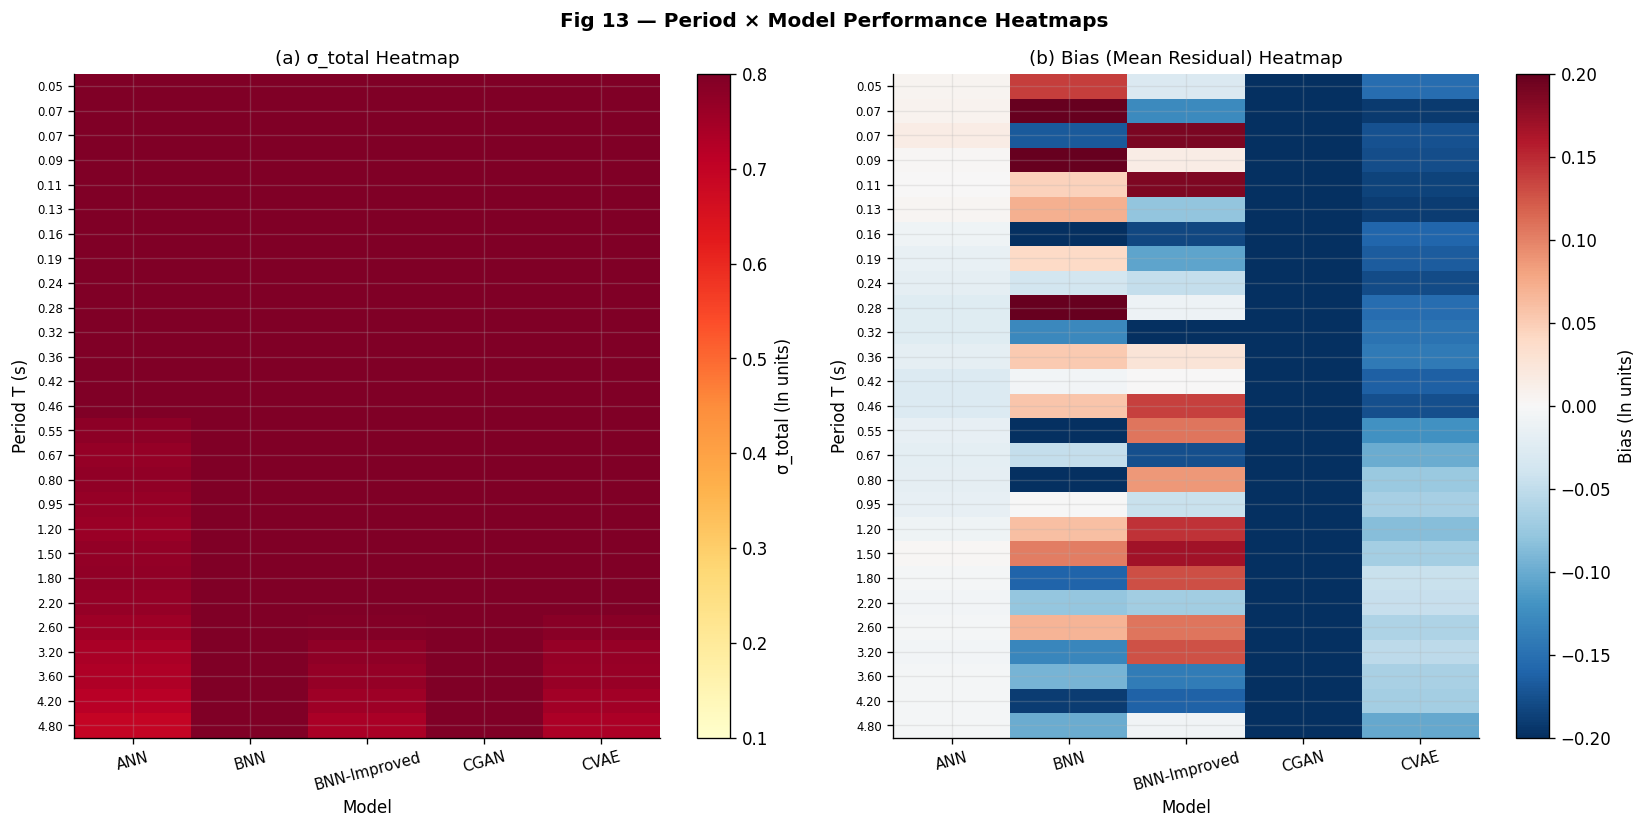

In [30]:
# ══════════════════════════════════════════════════════════════════
#  Fig 13  —  σ_total Heatmap (Period × Model)
# ══════════════════════════════════════════════════════════════════
T_plot_idx = np.where((T >= 0.05) & (T <= 5.0))[0][::3]
T_plot     = T[T_plot_idx]

sigma_mat = np.column_stack([metrics[m]['sigma'][T_plot_idx] for m in MODEL_NAMES])
bias_mat  = np.column_stack([metrics[m]['bias'][T_plot_idx]  for m in MODEL_NAMES])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

im = axes[0].imshow(sigma_mat, aspect='auto', cmap='YlOrRd', vmin=0.1, vmax=0.8)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(MODEL_NAMES, fontsize=9, rotation=15)
axes[0].set_yticks(range(len(T_plot))); axes[0].set_yticklabels([f'{t:.2f}' for t in T_plot], fontsize=7)
axes[0].set_xlabel('Model'); axes[0].set_ylabel('Period T (s)')
axes[0].set_title('(a) σ_total Heatmap')
plt.colorbar(im, ax=axes[0], label='σ_total (ln units)')

im2 = axes[1].imshow(bias_mat, aspect='auto', cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(MODEL_NAMES, fontsize=9, rotation=15)
axes[1].set_yticks(range(len(T_plot))); axes[1].set_yticklabels([f'{t:.2f}' for t in T_plot], fontsize=7)
axes[1].set_xlabel('Model'); axes[1].set_ylabel('Period T (s)')
axes[1].set_title('(b) Bias (Mean Residual) Heatmap')
plt.colorbar(im2, ax=axes[1], label='Bias (ln units)')

fig.suptitle('Fig 13 — Period × Model Performance Heatmaps', fontweight='bold')
plt.tight_layout()
plt.savefig('figures_comparison/fig13_performance_heatmaps.png'); plt.show()



══════ Summary Table (mean over all 105 periods) ══════
              Mean RMSE  Mean R²  Mean σ  Mean |Bias|  Train Time(s)
ANN              0.8179   0.8798  0.8177       0.0108         5.6498
BNN              1.0849   0.7889  1.0753       0.1206         3.2442
BNN-Improved     0.9188   0.8480  0.9110       0.0942        18.0860
CGAN             2.4326  -0.1375  1.3696       1.9444        22.5832
CVAE             0.8566   0.8684  0.8465       0.1227         6.2561


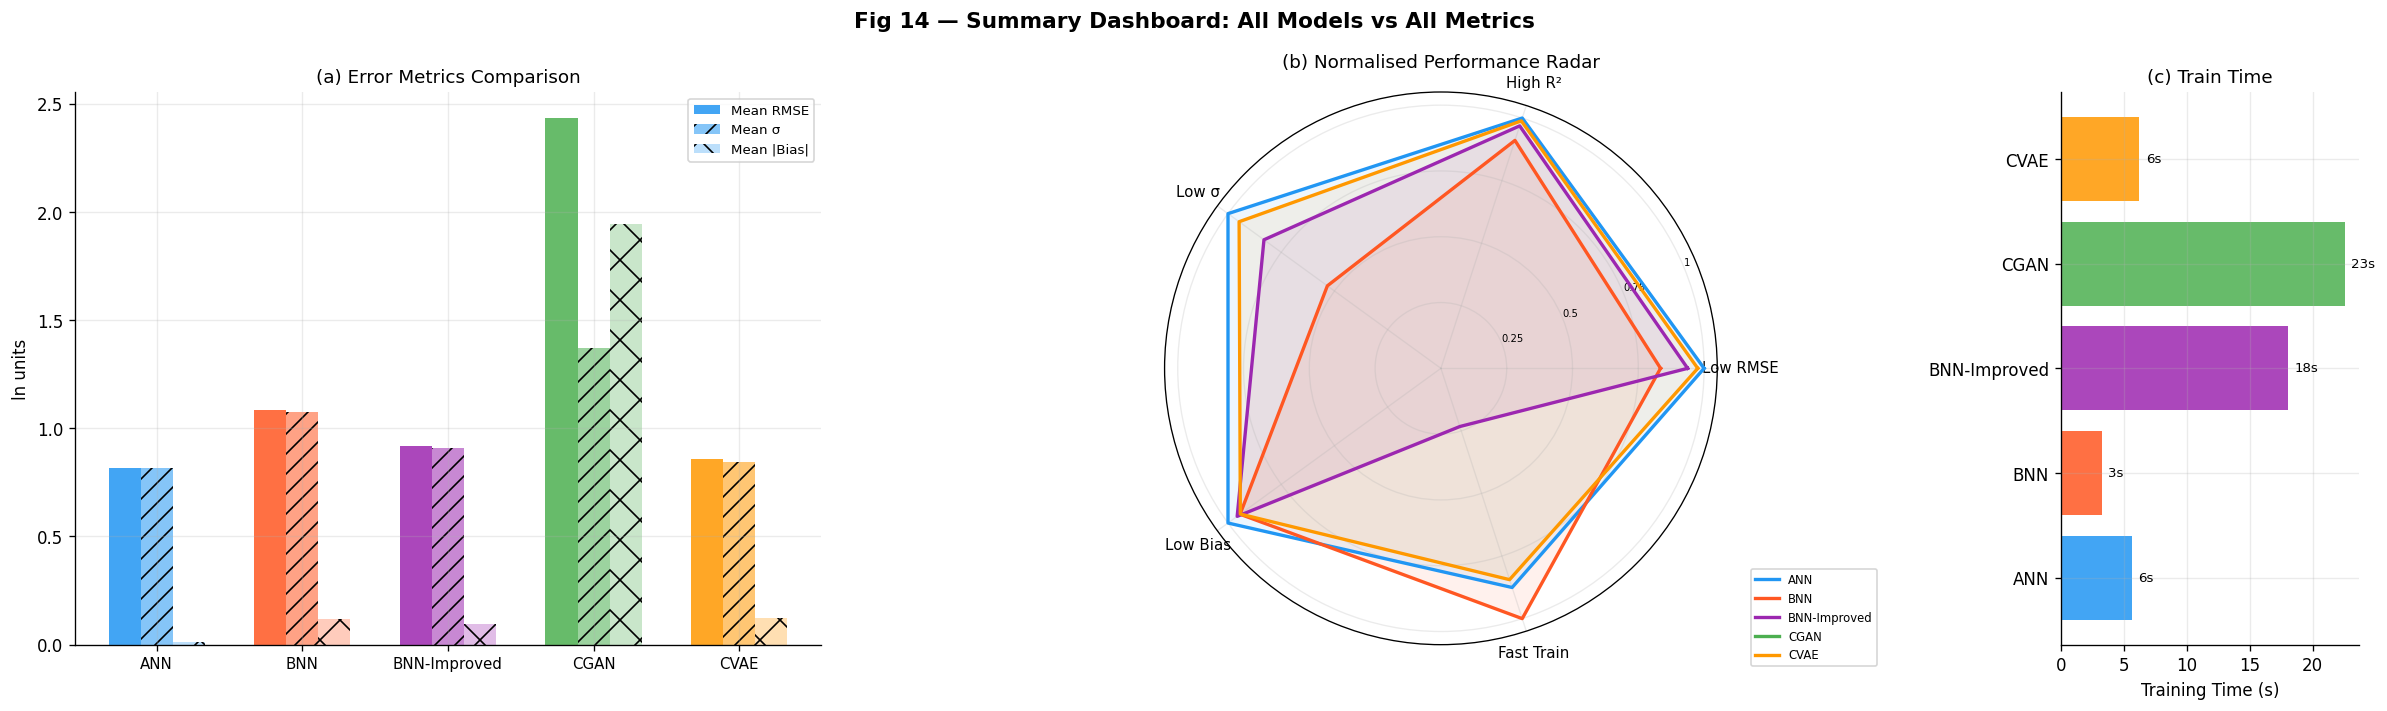

In [31]:
# ══════════════════════════════════════════════════════════════════
#  Fig 14  —  Summary Dashboard
#  (a) Overall metrics bar chart  (b) Radar chart  (c) Training cost
# ══════════════════════════════════════════════════════════════════
# Aggregate metrics (mean across all 105 periods)
summary = {}
for name in MODEL_NAMES:
    m = metrics[name]
    summary[name] = {
        'Mean RMSE'    : m['rmse'].mean(),
        'Mean R²'      : m['r2'].mean(),
        'Mean σ'       : m['sigma'].mean(),
        'Mean |Bias|'  : np.abs(m['bias']).mean(),
        'Train Time(s)': float({'ANN':ANN_TIME,'BNN':BNN_TIME,'BNN-Improved':BNNX_TIME,
                                'CGAN':CGAN_TIME,'CVAE':CVAE_TIME}[name]),
    }

df_sum = pd.DataFrame(summary).T
print("\n══════ Summary Table (mean over all 105 periods) ══════")
print(df_sum.round(4).to_string())

fig = plt.figure(figsize=(20, 6))
gs  = GridSpec(1, 3, figure=fig, width_ratios=[2.5, 2.5, 1])

# (a) Bar chart
ax1 = fig.add_subplot(gs[0])
x   = np.arange(len(MODEL_NAMES))
w   = 0.22
ax1.bar(x - w,   df_sum['Mean RMSE'],   w, color=[MODEL_COLORS[m] for m in MODEL_NAMES], alpha=0.85, label='Mean RMSE')
ax1.bar(x,       df_sum['Mean σ'],      w, color=[MODEL_COLORS[m] for m in MODEL_NAMES], alpha=0.55, label='Mean σ', hatch='//')
ax1.bar(x + w,   df_sum['Mean |Bias|'], w, color=[MODEL_COLORS[m] for m in MODEL_NAMES], alpha=0.30, label='Mean |Bias|', hatch='x')
ax1.set_xticks(x); ax1.set_xticklabels(MODEL_NAMES, fontsize=9)
ax1.set_ylabel('ln units'); ax1.set_title('(a) Error Metrics Comparison'); ax1.legend(fontsize=8)

# (b) Radar chart
cats   = ['Low RMSE','High R²','Low σ','Low Bias','Fast Train']
N_cats = len(cats)
angles = np.linspace(0, 2*np.pi, N_cats, endpoint=False).tolist()
angles += angles[:1]

# Normalise to [0,1] (lower = better, except R²)
rmse_norm  = 1 - (df_sum['Mean RMSE']   - df_sum['Mean RMSE'].min()) / (df_sum['Mean RMSE'].max() - df_sum['Mean RMSE'].min() + 1e-9)
r2_norm    =     (df_sum['Mean R²']     - df_sum['Mean R²'].min())   / (df_sum['Mean R²'].max()   - df_sum['Mean R²'].min()   + 1e-9)
sig_norm   = 1 - (df_sum['Mean σ']      - df_sum['Mean σ'].min())    / (df_sum['Mean σ'].max()    - df_sum['Mean σ'].min()    + 1e-9)
bias_norm  = 1 - (df_sum['Mean |Bias|'] - df_sum['Mean |Bias|'].min()) / (df_sum['Mean |Bias|'].max() - df_sum['Mean |Bias|'].min() + 1e-9)
time_norm  = 1 - (df_sum['Train Time(s)'] - df_sum['Train Time(s)'].min()) / (df_sum['Train Time(s)'].max() - df_sum['Train Time(s)'].min() + 1e-9)

ax2 = fig.add_subplot(gs[1], polar=True)
for name in MODEL_NAMES:
    vals = [rmse_norm[name], r2_norm[name], sig_norm[name], bias_norm[name], time_norm[name]]
    vals += vals[:1]
    ax2.plot(angles, vals, color=MODEL_COLORS[name], lw=2, label=name)
    ax2.fill(angles, vals, color=MODEL_COLORS[name], alpha=0.08)
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(cats, fontsize=9)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0]); ax2.set_yticklabels(['0.25','0.5','0.75','1'], fontsize=6)
ax2.set_title('(b) Normalised Performance Radar', pad=15); ax2.legend(loc='lower right', fontsize=7, bbox_to_anchor=(1.3,-0.05))

# (c) Training time
ax3 = fig.add_subplot(gs[2])
colors = [MODEL_COLORS[m] for m in MODEL_NAMES]
ax3.barh(MODEL_NAMES, df_sum['Train Time(s)'], color=colors, alpha=0.85)
ax3.set_xlabel('Training Time (s)'); ax3.set_title('(c) Train Time')
for i, (name, t) in enumerate(zip(MODEL_NAMES, df_sum['Train Time(s)'])):
    ax3.text(t+0.5, i, f'{t:.0f}s', va='center', fontsize=8)

fig.suptitle('Fig 14 — Summary Dashboard: All Models vs All Metrics', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('figures_comparison/fig14_summary_dashboard.png', dpi=150); plt.show()


## 6  ·  Export Results

In [32]:
# Save summary metrics to CSV
rows = []
for name in MODEL_NAMES:
    for i, t in enumerate(PERIOD_VALUES):
        rows.append({
            'Model'   : name,
            'Period_s': t,
            'RMSE'    : metrics[name]['rmse'][i],
            'R2'      : metrics[name]['r2'][i],
            'Sigma'   : metrics[name]['sigma'][i],
            'Bias'    : metrics[name]['bias'][i],
        })

df_metrics_all = pd.DataFrame(rows)
df_metrics_all.to_csv('figures_comparison/metrics_per_period_all_models.csv', index=False)
df_sum.to_csv('figures_comparison/summary_metrics.csv')

print("Saved:")
print("  figures_comparison/metrics_per_period_all_models.csv")
print("  figures_comparison/summary_metrics.csv")
print()
print("All figures saved to  figures_comparison/")
for f in sorted(os.listdir('figures_comparison')):
    if f.endswith('.png'): print(f"  {f}")


Saved:
  figures_comparison/metrics_per_period_all_models.csv
  figures_comparison/summary_metrics.csv

All figures saved to  figures_comparison/
  fig10_uncertainty_quantification.png
  fig11_bias_qqplot.png
  fig12_depth_fm_scaling.png
  fig13_performance_heatmaps.png
  fig14_summary_dashboard.png
  fig1_architecture_summary.png
  fig2_training_history.png
  fig3_metrics_vs_period.png
  fig4_predicted_vs_observed.png
  fig5_response_spectra_scenarios.png
  fig6_scaling_behaviour.png
  fig7_residuals_vs_predictors.png
  fig8_residuals_by_region.png
  fig9_sigma_decomposition.png
